In [1]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_ta as ta
import math
from tqdm import tqdm
import gc
import time
import json
import pandas_ta
import talib

# from position_tools import calculate_trades, calculate_positions, count_since_last_signal

# from pklibs import *

import logging

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


from pklib.strategy import *
from pklib.utilities import *


import optuna
optuna.logging.set_verbosity(optuna.logging.ERROR)

# You can use Matplotlib instead of Plotly for visualization by simply replacing `optuna.visualization` with
# `optuna.visualization.matplotlib` in the following examples.
from optuna.visualization import plot_contour
from optuna.visualization import plot_edf
from optuna.visualization import plot_intermediate_values
from optuna.visualization import plot_optimization_history
from optuna.visualization import plot_parallel_coordinate
from optuna.visualization import plot_param_importances
from optuna.visualization import plot_rank
from optuna.visualization import plot_slice
from optuna.visualization import plot_timeline

In [68]:
param_defs = {
    # 'ema_short_period': {'method': 'suggest_int', 'min': 10, 'max': 60},
    # 'ema_long_period': {
    #     'method': 'suggest_int', 
    #     'min': 61, 
    #     'max': 200,
    #     'min_depends_on': {
    #         'param': 'ema_short_period',
    #         'adjust_min': lambda ema_short: ema_short + 1
    #     }
    # },
    # 'ewo_enter': {'method': 'suggest_float', 'min': -1, 'max': 1},
    # 'ewo_exit': {'method': 'suggest_float', 'min': -1, 'max': 1},
    # 'ewo_thre_short': {'method': 'suggest_float', 'min': -1, 'max': -0.01},
    'ema_filter_period': {'method': 'suggest_int', 'min': 200, 'max': 600, 'step': 20},
    'up_lookback': {'method': 'suggest_int', 'min': 10, 'max': 100, 'step': 5},
    'dn_lookback': {'method': 'suggest_int', 'min': 10, 'max': 100, 'step': 5},
    'up_lag': {'method': 'suggest_int', 'min': 5, 'max': 100, 'step': 3},
    'dn_lag': {'method': 'suggest_int', 'min': 5, 'max': 100, 'step': 3},
    # 'band_offset': {'method': 'suggest_float', 'min': 0, 'max': 1.0},
    # 'band_offset_up': {'method': 'suggest_float', 'min': 0, 'max': 1.0},
    # 'band_offset_dn': {'method': 'suggest_float', 'min': 0, 'max': 1.0},
}

def calculate_ema_filter(data, params):    
    ema_filter_period = params['ema_filter_period']
    data['ema_filter'] = data['close'].rolling(ema_filter_period).mean()
    # data['ema_filter'] = data['close'].ewm(span=ema_filter_period).mean()
    
def calculate_ewo(data, params):
    ema_long_period = params['ema_long_period']
    ema_short_period = params['ema_short_period']
    data['ema_long'] = data['close'].ewm(span=ema_long_period).mean()
    data['ema_short'] = data['close'].ewm(span=ema_short_period).mean()
    data['ewo'] = (data['ema_short'] - data['ema_long']) / (data['close'] + 1e-6)

def calculate_donchian_channels(data, params):
    up_lookback = params['up_lookback']
    up_lag = params['up_lag']
    dn_lookback = params['dn_lookback']
    dn_lag = params['dn_lag']
    # band_offset = params['band_offset']
    # band_offset_up = params['band_offset_up']
    # band_offset_dn = params['band_offset_dn']
    data['donch_up'] = data['close'].rolling(window=up_lookback).max().shift(up_lag)
    data['donch_dn'] = data['close'].rolling(window=dn_lookback).min().shift(dn_lag)
    
    # data['donch_mid'] = (1 - band_offset) * data['donch_up'] + band_offset * data['donch_dn']
    # data['donch_mid_up'] = (1 - band_offset_up) * data['donch_up'] + band_offset_up * data['donch_dn']
    # data['donch_mid_dn'] = (1 - band_offset_dn) * data['donch_up'] + band_offset_dn * data['donch_dn']
    
def add_log_price_and_log_return(data, params):
    data['log_price'] = data['close'].apply(np.log)
    data['log_rets'] = data.log_price.diff()
    data.iloc[0]['log_rets'] = 0

def generate_bull_signal(data, params):    
    bull = (data['close'] > data['donch_up']) 
    return (
            (
                bull & (~bull.shift(fill_value=False)) 
                & (data['close'] > data['ema_filter'])
                # | (data['ewo'] < params['ewo_enter'])
            ).astype(int).shift(fill_value=0),
            (
            (data['close'] < data['donch_dn'])
            # | (data['ewo'] > params['ewo_exit'])
            ).astype(int).shift(fill_value=0),
            1
        )


def generate_bear_signal(data):
    return (
            (
                (data['close'] < data['donch_dn'])  #& (~data['donch_up'].isna()) & (~data['donch_dn'].isna())
            ).astype(int),
            (
            (data['close'] > data['donch_mid']) 
            ).astype(int),
            -1
        )


# Define indicators using params
indicators = [
    {'function': add_log_price_and_log_return},
    {'function': calculate_donchian_channels},
    {'function': calculate_ema_filter},
    # {'function': calculate_ewo},
    # Add more indicators here
]


def plot_indicators(ax, data):
    """
    Plots the indicators on the given axis.
    
    Parameters:
    ax (matplotlib.axes.Axes): The axis on which to plot.
    data (pd.DataFrame): The data containing the indicators to plot.
    """
    ax.plot(data.index, data['close'], label='Close Price', lw=0.5)
    ax.plot(data.index, data['donch_up'], label='Donchian Up', color='blue', lw=0.5)
    ax.plot(data.index, data['donch_dn'], label='Donchian Down', color='red', lw=0.5)
    ax.plot(data.index, data['ema_filter'], label='Ema Filter', color='green', lw=0.5)
    # ax.plot(data.index, data['donch_mid'], label='Donchian Mid', color='black', lw=0.5, linestyle='-')
    ax.legend(loc='best')
    ax.grid(axis='y')


In [69]:
# data.log_rets

===================  binance / BTC / 8h  =================================
params[ 0 ] = {'ema_filter_period': 220, 'up_lookback': 40, 'dn_lookback': 10, 'up_lag': 53, 'dn_lag': 95}
Metric                    |           Value
---------------------------------------------
Tot Return                |         42.2467
Max Drawdown              |         -0.3005
N Trades                  |         22.0000
Sharpe Ratio              |          0.4099
Sortino Ratio             |          3.1477
Avg Return                |          0.1868
Max Win                   |          3.4971
Max Loss                  |         -0.1657
Avg Win                   |          0.4222
Avg Loss                  |         -0.0862
Win Ratio                 |          0.5909
Profit Factor             |          5.6425
N Wins                    |         13.0000
N Losses                  |          9.0000
Avg Drawdown              |         -0.0793


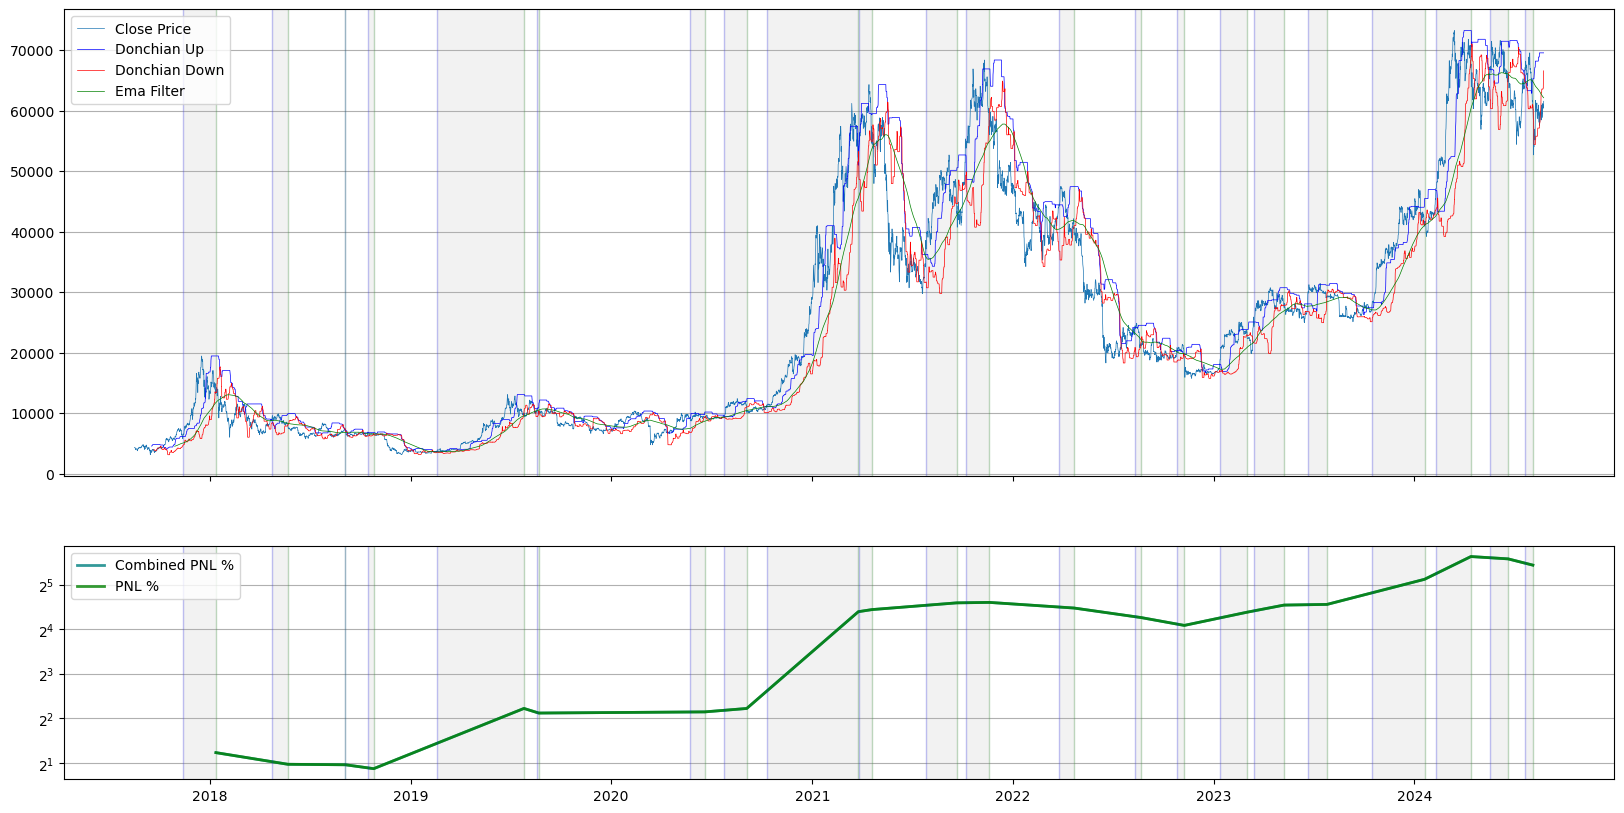

In [75]:

# Proceed with optimizing and testing as before

optuna.logging.set_verbosity(optuna.logging.ERROR)
# Load the data
# asset = 'TSLA'
# data = load_sp500_stock_candles(asset)['2010':'2025']
# data['close'] = data['adj close']
# data = load_russel2000_candles('XOXO')['2006':]
asset, quote, timeframe, exchange = 'BTC', 'USDT', '8h', 'binance'
data = load_candles('binance',asset, quote, timeframe)#['2020':'2025']#.iloc[-35000:-5000]
# .assign(log_price=lambda df:df['close'].apply(np.log)
# ).assign(log_rets=lambda df:df.log_price.diff())
nhours = 6; train_ratio = 1; enable_long=True; enable_short=True
btargs = {'transaction_cost':0.001, 'slippage':0.003, 'precision':3, 'period_costs':0}

# data = data.resample(f'{nhours}H').agg({'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'})
# data = data.iloc[:int(data.shape[0]*train_ratio)]; data_test = data.iloc[data.shape[0]:]
study = optimize(data, param_defs, indicators, generate_bull_signal, btargs, xmult=1, n_trials=100, 
                 optimize_metrics=['tot_return'])
aparams = [t.params for t in reversed(study.best_trials[-10:])]
# def custom_metric(metrics):
#     return metrics['overall_metrics']['tot_return'] / abs(metrics['overall_metrics']['max_drawdown'])

# study = optimize(
#   sortino  data, 
#     nhours, 
#     param_defs, 
#     optimize_metrics=['overall_metrics.max_drawdown', 'short_metrics.profit_factor'],
#     directions=['maximize', 'maximize'],
#     n_trials=100
# )
# aparams = [t.params for t in reversed(study.best_trials[-10:])]

    
for ipa, params in enumerate(aparams[:]):
    print(f'===================  {exchange} / {asset} / {timeframe}  =================================')
    print(f'params[ {ipa} ] = {params}')
    if len(data): 
        # print('--- TRAIN -----------------------------------------------------')
        entry_indices, exit_indices, metrics = comp_backtest(data,params,indicators,generate_indicators,generate_bull_signal)
        plot_strategy(data,metrics,entry_indices,exit_indices,plot_indicators)
        # generate_indicators(data,params,indicators)
        # enter_sigs, exit_sigs, xmult = generate_bull_signal(data,params)
        # skip_first = max(params['up_lookback']+params['up_lag'], params['dn_lookback']+params['dn_lag'])
        # entry_indices, exit_indices, metrics = backtest(data.log_price, enter_sigs, exit_sigs, skip_first, xmult, transaction_cost=0.001, slippage=0.003, precision=3, period_costs=None)

        
        


In [252]:
study.best_trials


[FrozenTrial(number=96, state=TrialState.COMPLETE, values=[3.876389462845738, 0.3038331514227106], datetime_start=datetime.datetime(2024, 8, 28, 3, 28, 53, 309001), datetime_complete=datetime.datetime(2024, 8, 28, 3, 28, 53, 312963), params={'ema_short_period': 56, 'ema_long_period': 122, 'ewo_enter': -0.9517685955053861, 'ewo_exit': 0.41511480963856395, 'up_lookback': 81, 'dn_lookback': 97, 'up_lag': 6, 'dn_lag': 18, 'band_offset': 0.810892336731394}, user_attrs={}, system_attrs={'nsga2:generation': 1}, intermediate_values={}, distributions={'ema_short_period': IntDistribution(high=60, log=False, low=10, step=1), 'ema_long_period': IntDistribution(high=200, log=False, low=57, step=1), 'ewo_enter': FloatDistribution(high=1.0, log=False, low=-1.0, step=None), 'ewo_exit': FloatDistribution(high=1.0, log=False, low=-1.0, step=None), 'up_lookback': IntDistribution(high=100, log=False, low=10, step=1), 'dn_lookback': IntDistribution(high=100, log=False, low=10, step=1), 'up_lag': IntDistrib

Metric                    |           Value
---------------------------------------------
Tot Return                |          7.1131
Max Drawdown              |         -0.7367
N Trades                  |         20.0000
Sharpe Ratio              |          0.2038
Sortino Ratio             |          0.8611
Avg Return                |          0.1103
Max Win                   |          2.1409
Max Loss                  |         -0.4093
Avg Win                   |          0.7857
Avg Loss                  |         -0.1911
Win Ratio                 |          0.4000
Profit Factor             |          1.8226
N Wins                    |          8.0000
N Losses                  |         12.0000
Avg Drawdown              |         -0.2894


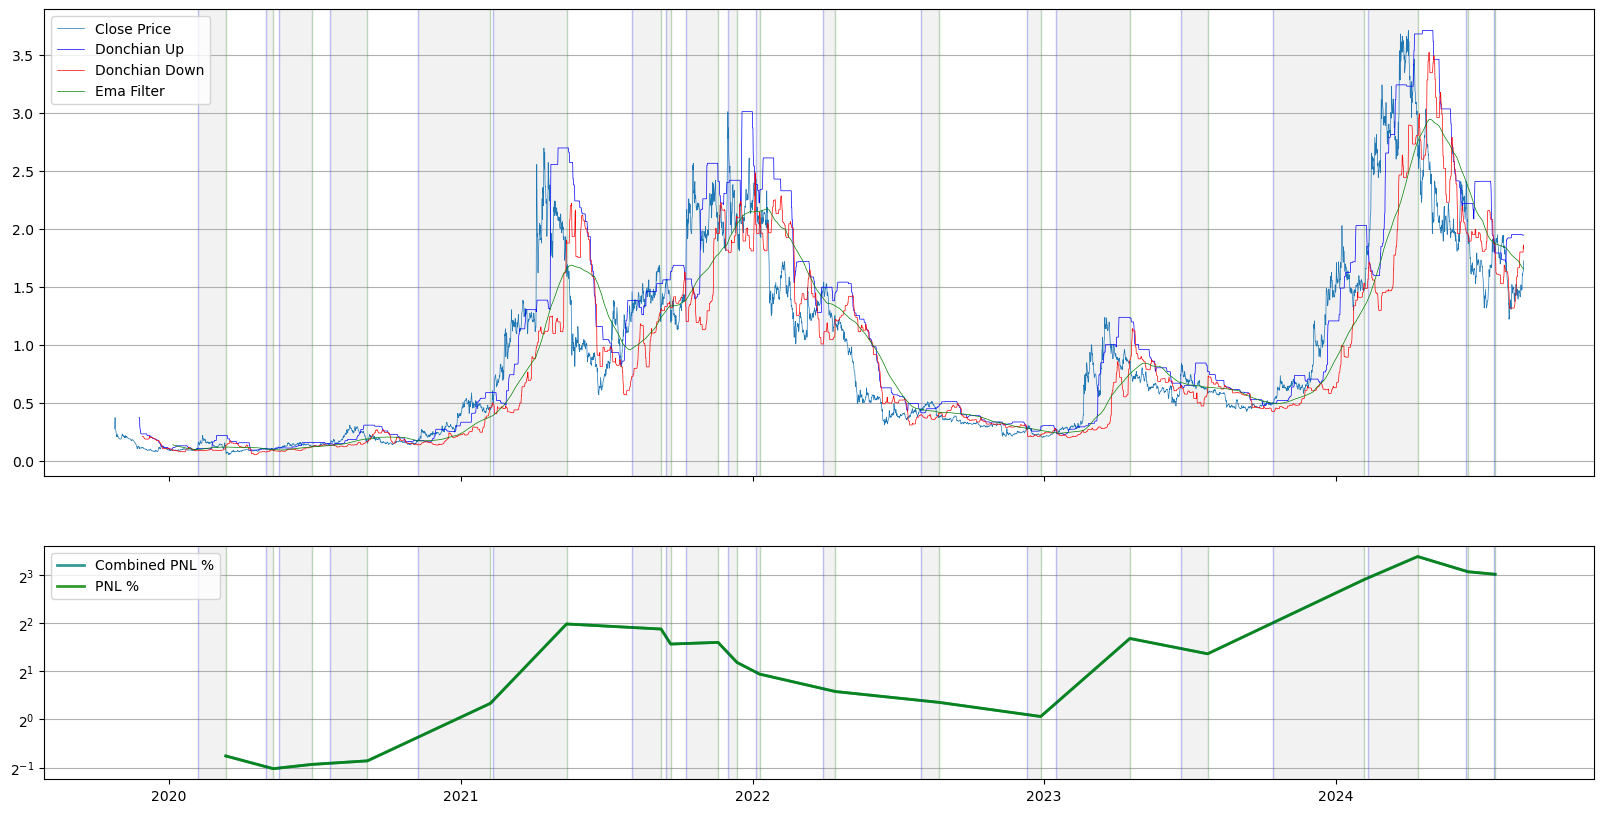

In [83]:
asset = 'STX'
data = load_candles('binance',asset, quote, timeframe)#['2020':'2025']#.iloc[-35000:-5000]
entry_indices, exit_indices, metrics = comp_backtest(data,params,indicators,generate_indicators,generate_bull_signal)
plot_strategy(data,metrics,entry_indices,exit_indices,plot_indicators)


## Parameer analysis

In [ ]:
optuna.visualization.plot_param_importances(
    study, target=lambda t: t.duration.total_seconds(), target_name="duration"
)

In [ ]:
optuna.visualization.plot_pareto_front(study, target_names=["tot_return", "trade_max_drawdown"])

In [ ]:
plot_edf(study,target=lambda s: s.values[0])

In [ ]:
fig = plot_rank(study,target=lambda s: s.values[0])
plt.tight_layout()
fig


In [ ]:
plot_timeline(study)

In [ ]:
fig = plot_intermediate_values(study)

# fig.update_layout(
#     title="Hyperparameter optimization for Donchian Breakout strategy",
#     xaxis_title="Epoch",
#     yaxis_title="tot_return",
# )
fig

In [ ]:
for params in [t.params for t in study.best_trials]:
    print(f'params = {params}')
    print_performance(data,nhours,params,backtest_fn=backtest,short_long=short_long, xmult=1)

## Backtest a list of params on a bunch of assets

#### Load and map assets to existing data from exchanges

In [77]:
import os
btimeframe = timeframe
# btimeframe = '4h'
base_data_dir = "/media/mu6mula/Data/Crypto-Data-Feed/freq-user-data/data"
# quote, timeframe, nhours = 'USDT', '8h', 8
exchanges = ['binance', 'kucoin', 'bybit', 'bitget']
# with open("assets-portfolio.txt", "r") as file: assets = [line.strip() for line in file.readlines()][:20]
with open("top100MarketCap.txt", "r") as file: assets = [line.strip() for line in file.readlines()]#[:50]
# assets = filter(lambda a: not 'USD' in a, assets)
assets = [a for a in assets if 'USD' not in a and a not in ['LUNA', 'RENDER']]
# assets
# df_pf = pd.DataFrame(assets,columns=['asset'])
dfae = pd.DataFrame([
    [(os.path.exists(f'{base_data_dir}/{exchange}/{asset}_{quote}-{btimeframe}.json')) for exchange in exchanges]
    for asset in assets
]).set_axis(exchanges, axis=1)#.set_axis(assets,axis=0)
dfae.index = assets

dfae['first_exch'] = dfae.apply(lambda row: row.idxmax() if row.any() else None, axis=1)
# assets, exchanges = 
assets, exchanges = (dfae[~dfae['first_exch'].isna()][['first_exch']].reset_index().T.values)
asset_exchange = list(dfae[~dfae['first_exch'].isna()][['first_exch']].to_records())
# asset_exchange
# list(asset_exch)



In [95]:
dfae.loc['KCS':,:]
# asset_exchange

,binance,kucoin,bybit,bitget,first_exch
KCS,False,True,False,False,kucoin
BTT,False,True,False,False,kucoin
1000SATS,True,False,False,False,binance
ASTR,True,True,False,False,binance
CHZ,True,True,False,False,binance
MANA,True,True,False,False,binance
PYTH,True,True,False,False,binance
ETHDYDX,False,False,False,False,None
NEO,True,True,False,False,binance
BONK,True,True,False,False,binance


#### Backtest and collect results

In [78]:
def xtract_primitive_values(opt_bt) : 
    return {k:v for (k,v) in opt_bt.items() if not (isinstance(v,pd.Series) or isinstance(v,pd.Index)  or isinstance(v,np.ndarray))}

def remove_keys_with_unwanted_values(d):
    """
    Recursively remove keys from a dictionary if their values are
    instances of list, numpy array, pandas Series, or pandas DataFrame.
    """
    if not isinstance(d, dict):
        return d

    keys_to_remove = [key for key, value in d.items() if isinstance(value, (list, np.ndarray, pd.Series, pd.DataFrame, pd.DatetimeIndex))]

    for key in keys_to_remove:
        del d[key]

    # Recursively apply the function to sub-dictionaries
    for key, value in d.items():
        if isinstance(value, dict):
            remove_keys_with_unwanted_values(value)
    
    return d

In [79]:
# quote, timeframe, nhours = 'USDT', '4h', 4
# inc_metrics = ['asset', 'ipa', 'long_metrics', 'short_metrics', 'overall_metrics', 'rsi_period', 'up_rsi_thre', 'up_lookback', 'dn_lookback', 'up_lag', 'dn_lag', 'band_offset', 'count_since_last_cross']

bt_resa = []
for asset,exchange in tqdm(asset_exchange):
    # print(f'Processing {asset} / {exchange} / {btimeframe}')
    data = load_candles(exchange,asset,quote,btimeframe)['2020':]
    # data = data.resample(f'{nhours}H').agg({'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'})
    for ipa,params in enumerate(aparams):
        entry_indices, exit_indices, metrics = comp_backtest(data,params,indicators,generate_indicators,generate_bull_signal)
        if entry_indices is None:
            continue
        bt_resa.append({'exchange': exchange, 'asset': asset, 'tfr': btimeframe, 'ipa': ipa, **remove_keys_with_unwanted_values(metrics), ** params})
                

  0%|          | 0/88 [00:00<?, ?it/s]

100%|██████████| 88/88 [00:00<00:00, 118.37it/s]


In [99]:
from collections.abc import MutableMapping

    
# def flatten_dict(d, parent_key='', sep='.'):
#     items = []
#     for k, v in d.items():
#         new_key = f'{parent_key}{sep}{k}' if parent_key else k
#         if isinstance(v, MutableMapping):
#             items.extend(flatten_dict(v, new_key, sep=sep).items())
#         else:
#             items.append((new_key, v))
#     return dict(items)


# flattened_data = [flatten_dict(item) for item in bt_resa]

df = pd.DataFrame(bt_resa)
# df.columns = pd.MultiIndex.from_tuples([tuple(col.split('.')) for col in df.columns], names=['Category', 'Type'])
df = df[['exchange', 'asset', 'tfr', 'ipa', 'tot_return', 'max_drawdown', 'n_trades', 'win_ratio', 'avg_return',
       'avg_win', 'avg_loss', 'avg_drawdown', 'max_win', 'max_loss', 'profit_factor',
       'n_wins', 'n_losses', 'sharpe_ratio',
       'sortino_ratio', 'up_lookback', 'dn_lookback',
       'up_lag', 'dn_lag']]

df[['tot_return', 'max_drawdown', 'avg_return', 'avg_win', 'avg_loss', 'avg_drawdown', 'max_win', 'max_loss']] = df[['tot_return', 'max_drawdown', 'avg_return', 'avg_win', 'avg_loss', 'avg_drawdown', 'max_win', 'max_loss']].apply(np.expm1)

df[['tot_return', 'max_drawdown', 'win_ratio', 'avg_return','avg_win', 'avg_loss', 'avg_drawdown', 'max_win', 'max_loss', 'profit_factor', 'sharpe_ratio']] = df[['tot_return', 'max_drawdown', 'win_ratio', 'avg_return','avg_win', 'avg_loss', 'avg_drawdown', 'max_win', 'max_loss', 'profit_factor', 'sharpe_ratio']].round(2)

df.to_csv(f'asset_donch_backtest--{btimeframe}.csv', index=False)
print(f'aparams={aparams}')
# df.sort_values(('tot_return'))#.head(50)
# df = df.loc[df.groupby(['asset'])['tot_return'].idxmax()]
# df.groupby('asset', axis=1).apply(
#     lambda x: x.loc[x[ ('tot_return')].idxmax()])
# df = df[df['tot_return'] < 300]
print(f'length: {df.shape[0]}')
df = df.sort_values(('tot_return'), ascending=False)
df

aparams=[{'ema_filter_period': 220, 'up_lookback': 40, 'dn_lookback': 10, 'up_lag': 53, 'dn_lag': 95}]
length: 87


,exchange,asset,tfr,ipa,tot_return,max_drawdown,n_trades,win_ratio,avg_return,avg_win,...,max_loss,profit_factor,n_wins,n_losses,sharpe_ratio,sortino_ratio,up_lookback,dn_lookback,up_lag,dn_lag
53,binance,FTM,8h,0,945.57,-0.57,14.0,0.43,0.63,2.97,...,-0.34,5.82,6.0,8.0,0.49,3.715761,40,10,53,95
7,binance,DOGE,8h,0,96.47,-0.53,20.0,0.30,0.26,1.75,...,-0.18,4.06,6.0,14.0,0.29,3.414131,40,10,53,95
38,binance,RUNE,8h,0,71.82,-0.28,10.0,0.70,0.54,0.95,...,-0.20,11.71,7.0,3.0,0.52,5.380529,40,10,53,95
3,binance,SOL,8h,0,60.59,-0.28,14.0,0.50,0.34,1.01,...,-0.18,6.39,7.0,7.0,0.41,4.727891,40,10,53,95
58,binance,SAND,8h,0,50.93,-0.48,13.0,0.46,0.36,1.37,...,-0.23,4.22,6.0,7.0,0.38,3.803116,40,10,53,95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44,kucoin,BSV,8h,0,-0.66,-0.74,24.0,0.25,-0.04,0.14,...,-0.36,0.41,6.0,18.0,-0.29,-0.433150,40,10,53,95
52,binance,DYM,8h,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,40,10,53,95
66,binance,PYTH,8h,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,40,10,53,95
80,binance,MANTA,8h,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,40,10,53,95


***** binance, FTM, 8h, 0
Metric                    |           Value
---------------------------------------------
Tot Return                |        639.2546
Max Drawdown              |         -0.5670
N Trades                  |         16.0000
Sharpe Ratio              |          0.4210
Sortino Ratio             |          3.4440
Avg Return                |          0.4976
Max Win                   |         15.3910
Max Loss                  |         -0.3384
Avg Win                   |          2.9721
Avg Loss                  |         -0.1659
Win Ratio                 |          0.3750
Profit Factor             |          4.5623
N Wins                    |          6.0000
N Losses                  |         10.0000
Avg Drawdown              |         -0.1423


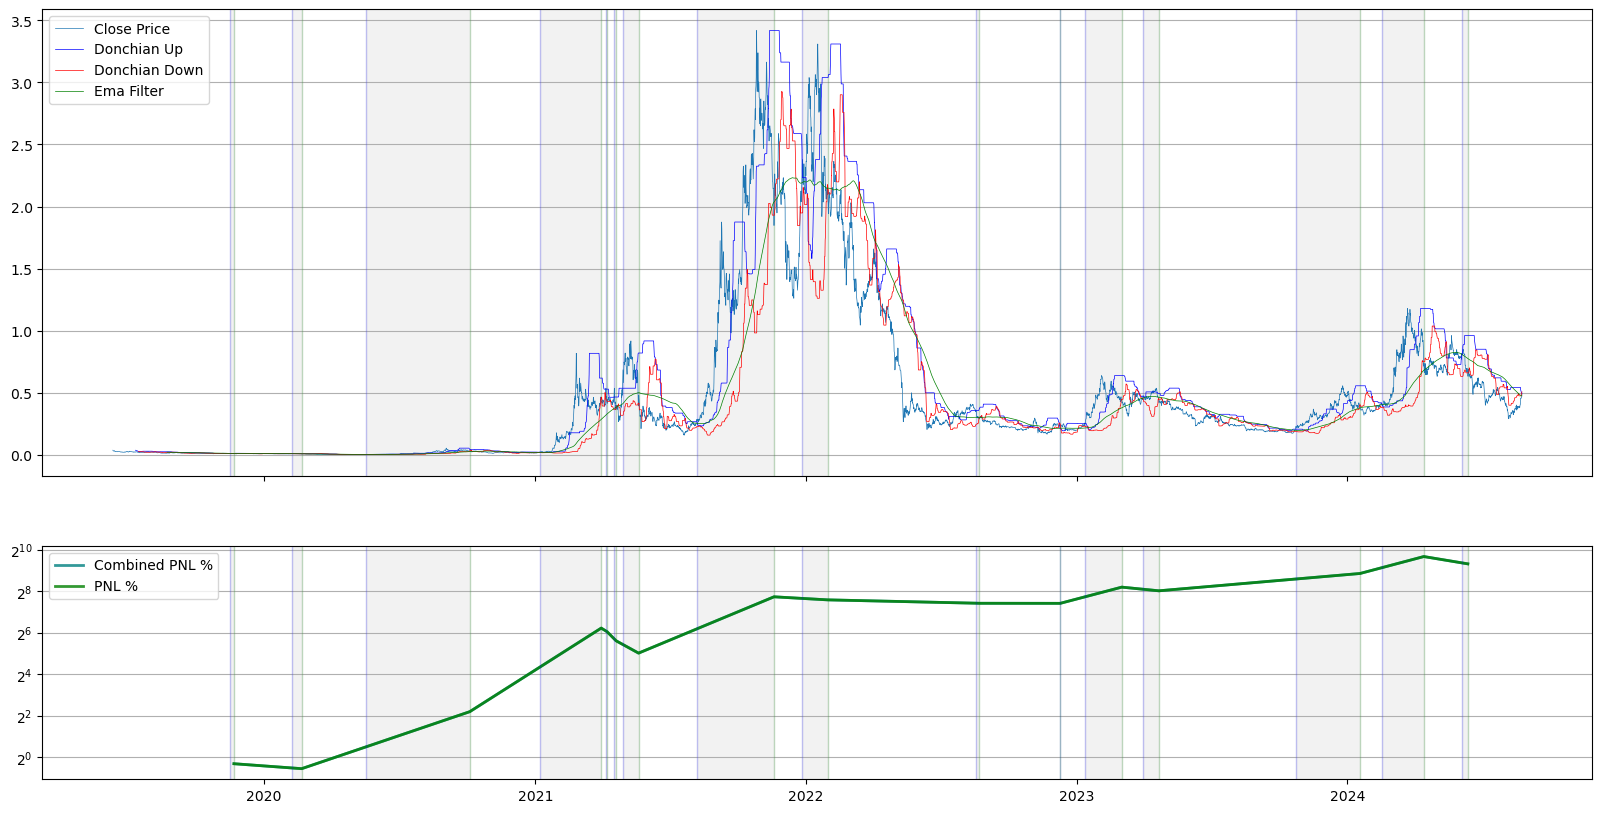

***** binance, DOGE, 8h, 0
Metric                    |           Value
---------------------------------------------
Tot Return                |         79.0482
Max Drawdown              |         -0.5326
N Trades                  |         23.0000
Sharpe Ratio              |          0.2540
Sortino Ratio             |          2.9302
Avg Return                |          0.2099
Max Win                   |         22.0797
Max Loss                  |         -0.1817
Avg Win                   |          1.7536
Avg Loss                  |         -0.0949
Win Ratio                 |          0.2609
Profit Factor             |          3.5858
N Wins                    |          6.0000
N Losses                  |         17.0000
Avg Drawdown              |         -0.2476


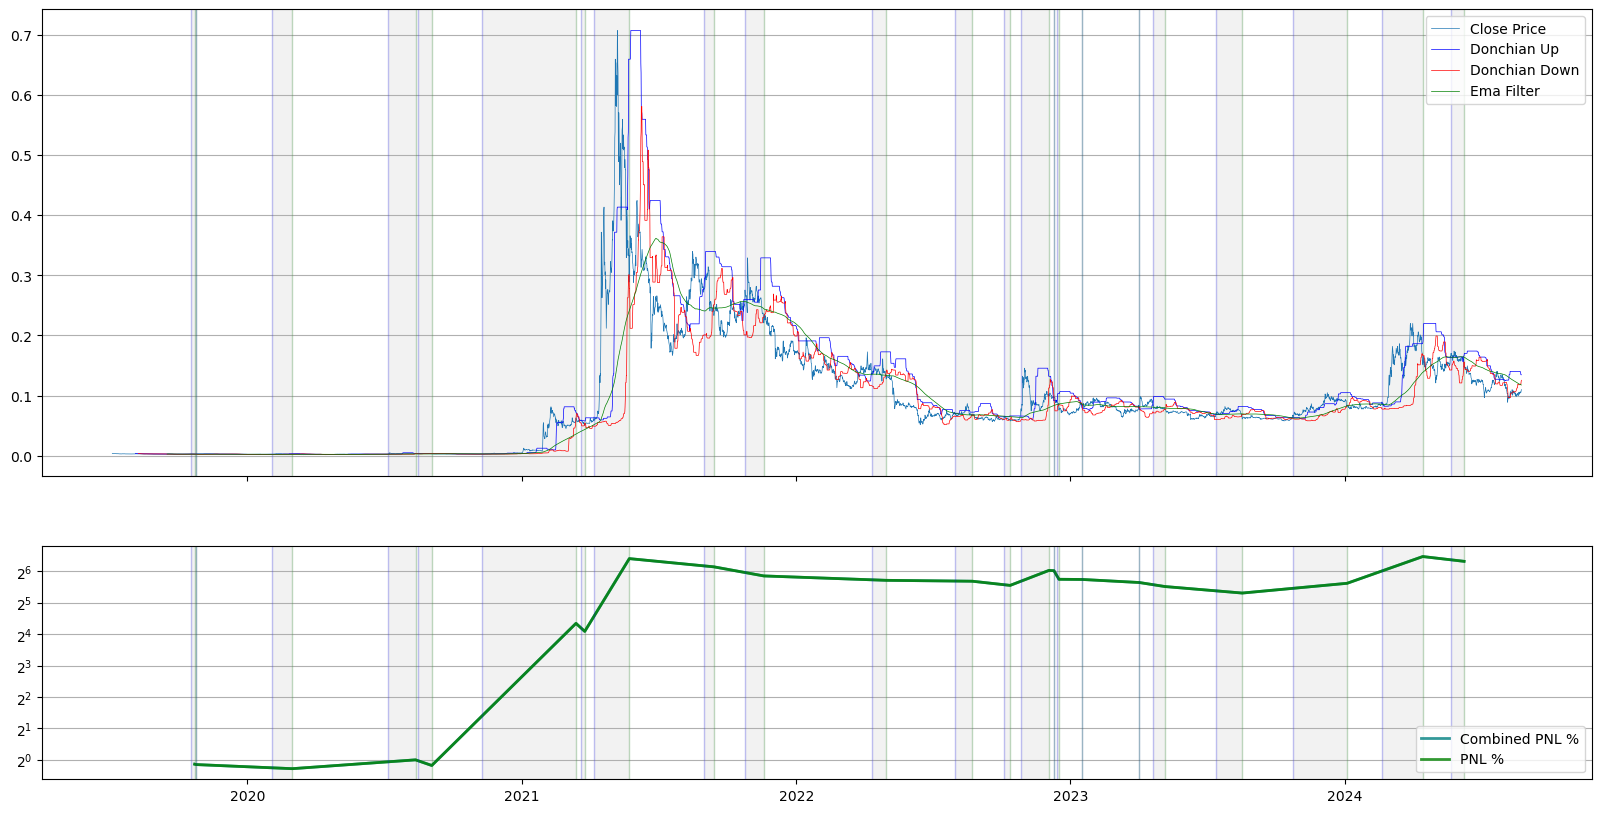

***** binance, RUNE, 8h, 0
Metric                    |           Value
---------------------------------------------
Tot Return                |         71.8243
Max Drawdown              |         -0.2837
N Trades                  |         10.0000
Sharpe Ratio              |          0.5180
Sortino Ratio             |          5.3805
Avg Return                |          0.5354
Max Win                   |         12.5775
Max Loss                  |         -0.1989
Avg Win                   |          0.9538
Avg Loss                  |         -0.1250
Win Ratio                 |          0.7000
Profit Factor             |         11.7054
N Wins                    |          7.0000
N Losses                  |          3.0000
Avg Drawdown              |         -0.0802


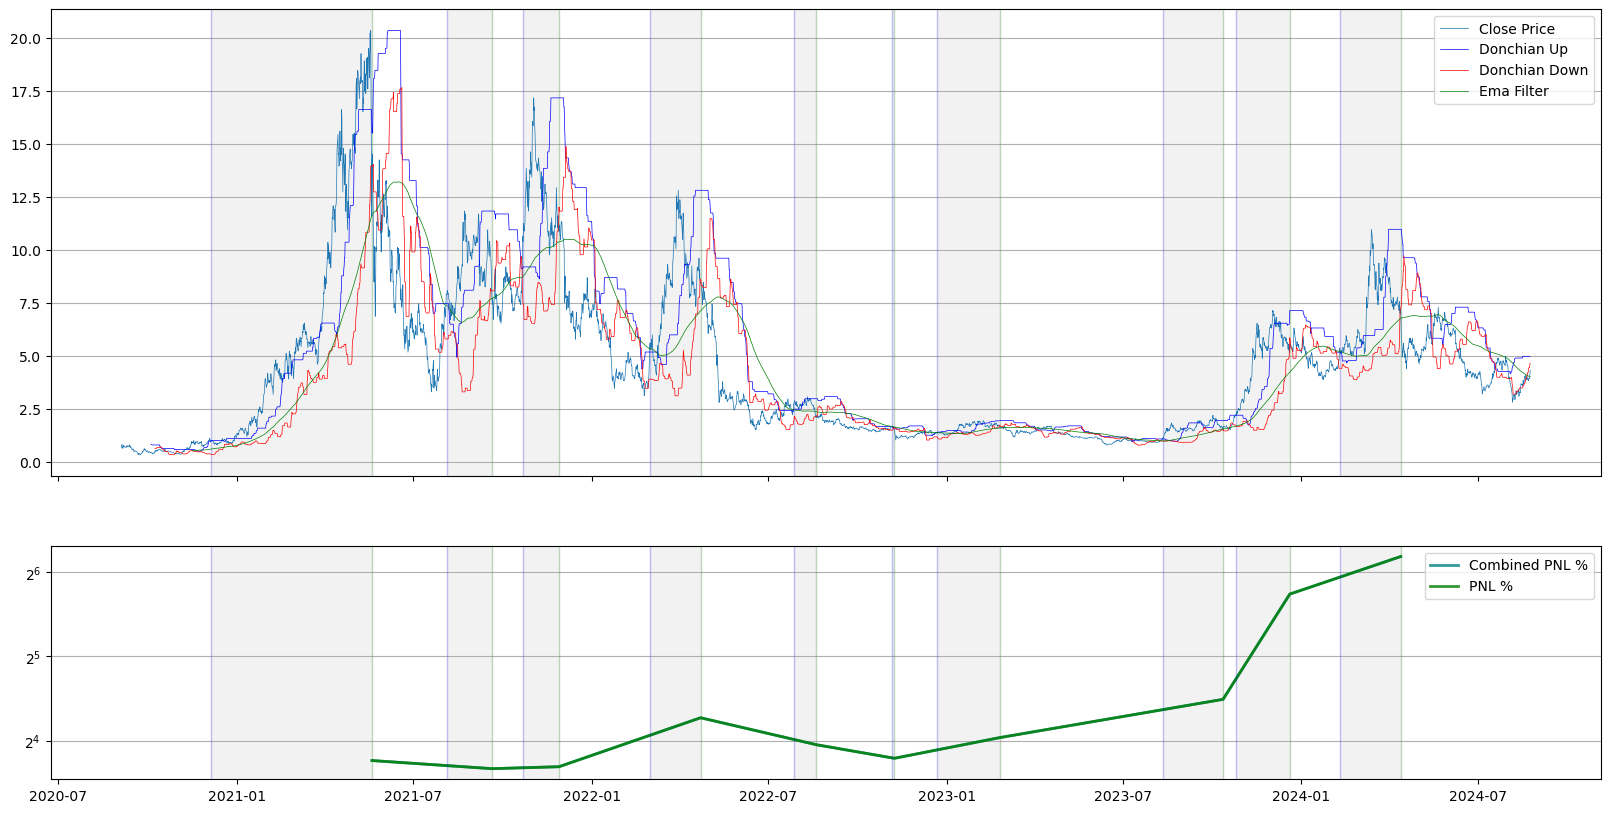

***** binance, SOL, 8h, 0
Metric                    |           Value
---------------------------------------------
Tot Return                |         60.5912
Max Drawdown              |         -0.2799
N Trades                  |         14.0000
Sharpe Ratio              |          0.4052
Sortino Ratio             |          4.7279
Avg Return                |          0.3422
Max Win                   |          9.7630
Max Loss                  |         -0.1813
Avg Win                   |          1.0095
Avg Loss                  |         -0.1035
Win Ratio                 |          0.5000
Profit Factor             |          6.3891
N Wins                    |          7.0000
N Losses                  |          7.0000
Avg Drawdown              |         -0.0947


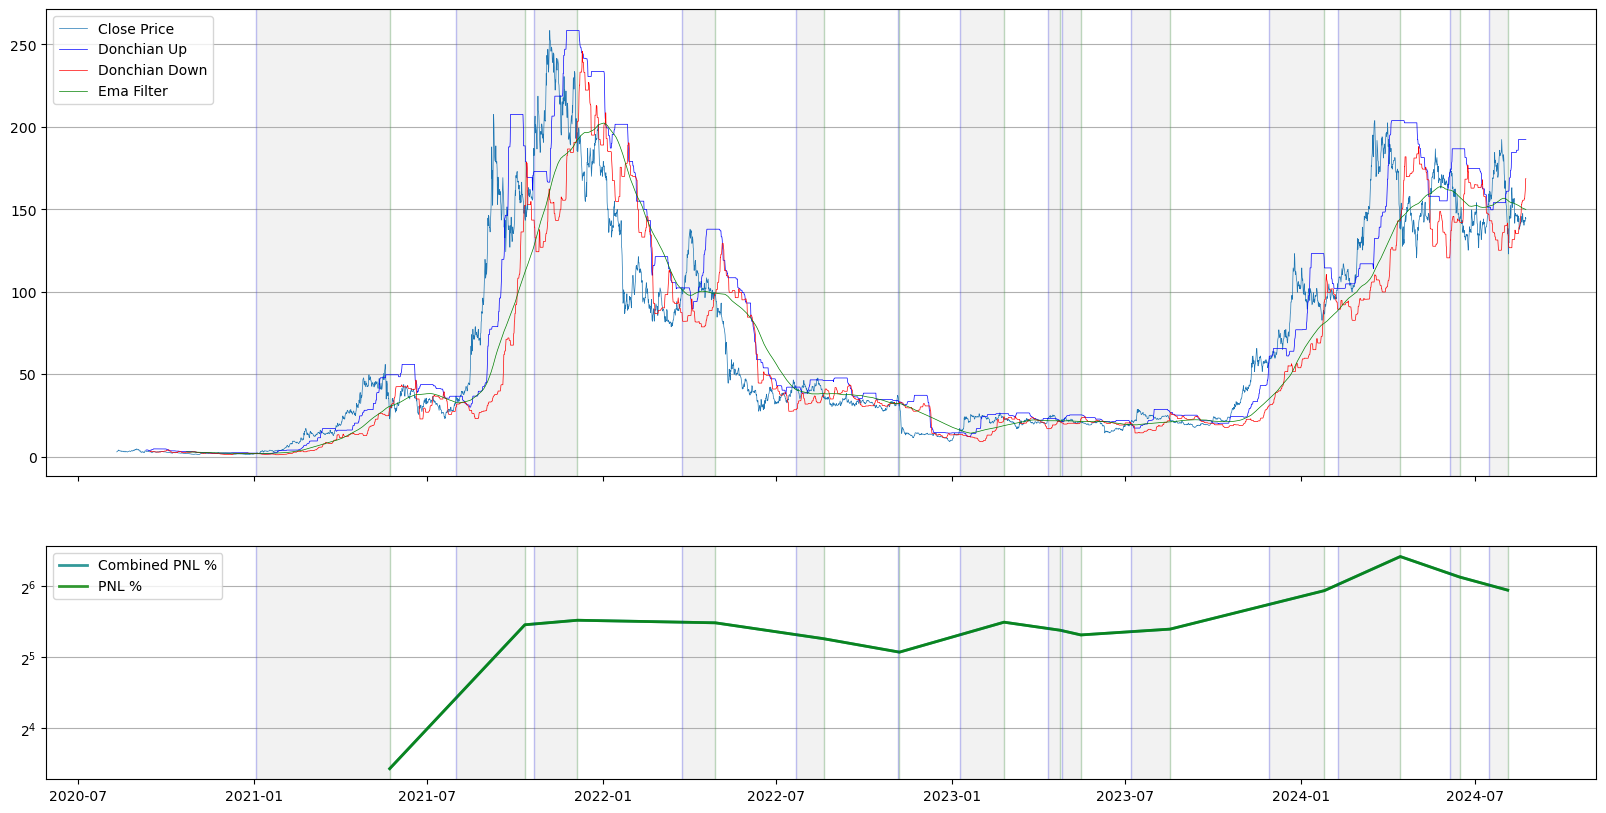

***** binance, SAND, 8h, 0
Metric                    |           Value
---------------------------------------------
Tot Return                |         50.9334
Max Drawdown              |         -0.4778
N Trades                  |         13.0000
Sharpe Ratio              |          0.3759
Sortino Ratio             |          3.8031
Avg Return                |          0.3551
Max Win                   |          8.5199
Max Loss                  |         -0.2275
Avg Win                   |          1.3698
Avg Loss                  |         -0.1608
Win Ratio                 |          0.4615
Profit Factor             |          4.2195
N Wins                    |          6.0000
N Losses                  |          7.0000
Avg Drawdown              |         -0.1977


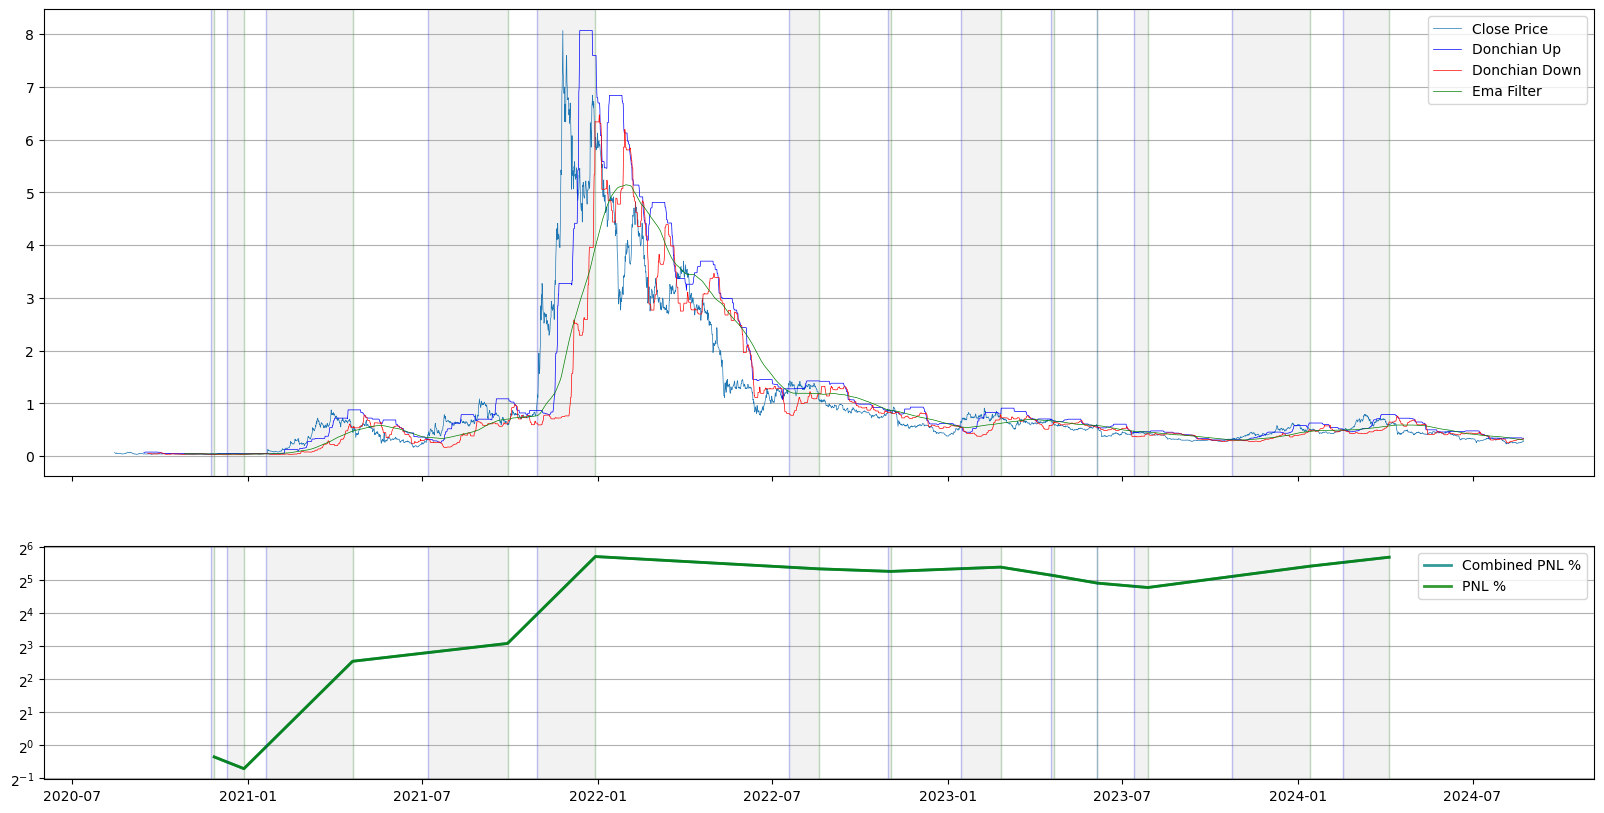

***** binance, AVAX, 8h, 0
Metric                    |           Value
---------------------------------------------
Tot Return                |         35.0065
Max Drawdown              |         -0.5676
N Trades                  |         14.0000
Sharpe Ratio              |          0.3446
Sortino Ratio             |          1.7288
Avg Return                |          0.2917
Max Win                   |          5.7754
Max Loss                  |         -0.3591
Avg Win                   |          1.7471
Avg Loss                  |         -0.1506
Win Ratio                 |          0.3571
Profit Factor             |          3.4395
N Wins                    |          5.0000
N Losses                  |          9.0000
Avg Drawdown              |         -0.1785


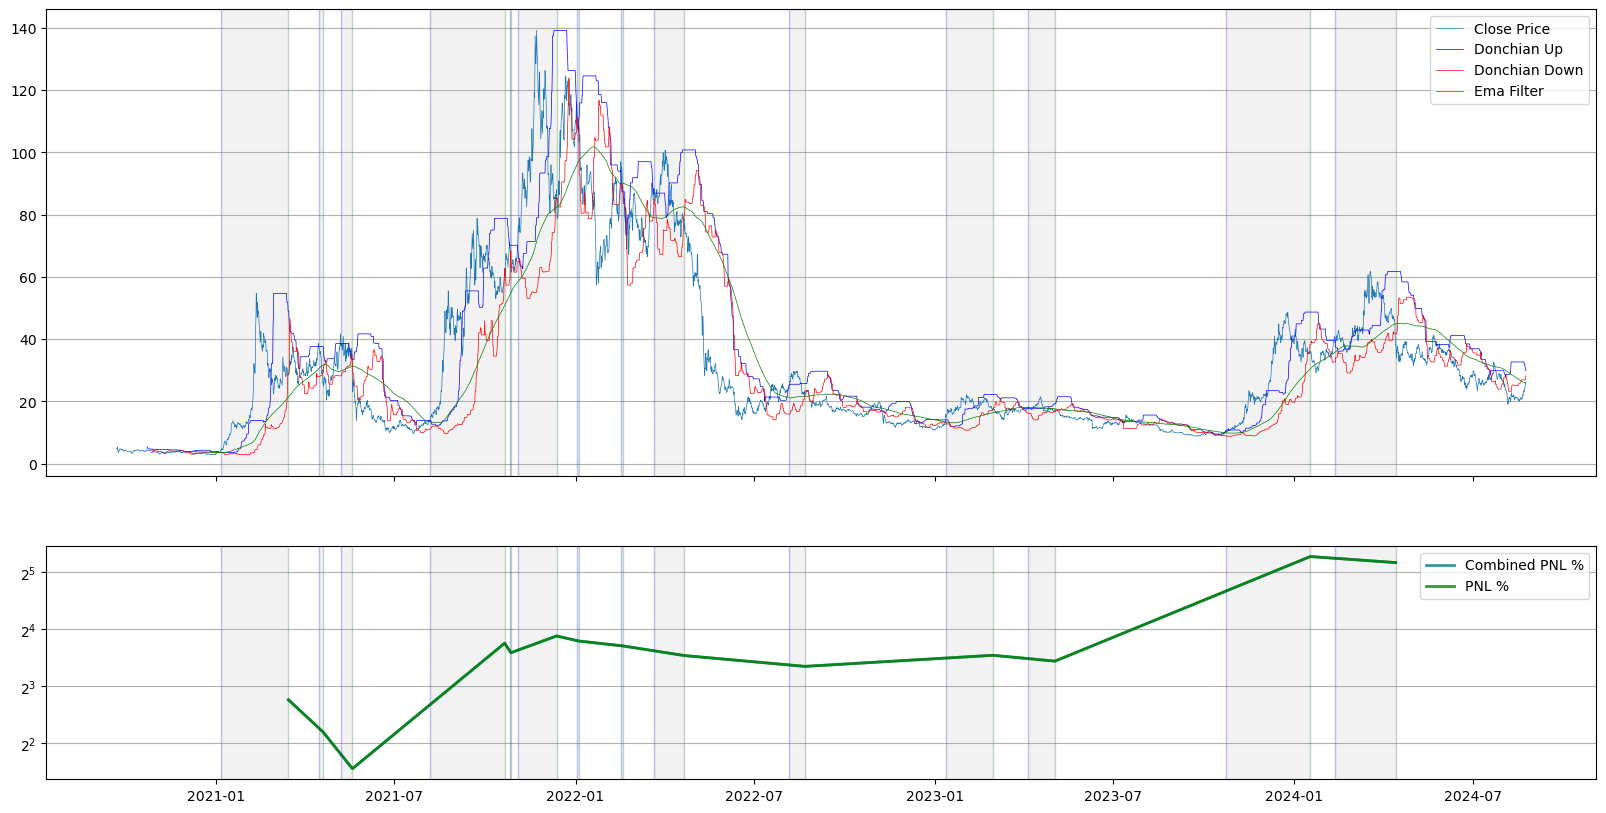

***** binance, MATIC, 8h, 0
Metric                    |           Value
---------------------------------------------
Tot Return                |         14.6647
Max Drawdown              |         -0.6528
N Trades                  |         23.0000
Sharpe Ratio              |          0.1851
Sortino Ratio             |          1.5343
Avg Return                |          0.1271
Max Win                   |         14.1600
Max Loss                  |         -0.2551
Avg Win                   |          0.9971
Avg Loss                  |         -0.1225
Win Ratio                 |          0.3043
Profit Factor             |          2.3163
N Wins                    |          7.0000
N Losses                  |         16.0000
Avg Drawdown              |         -0.2340


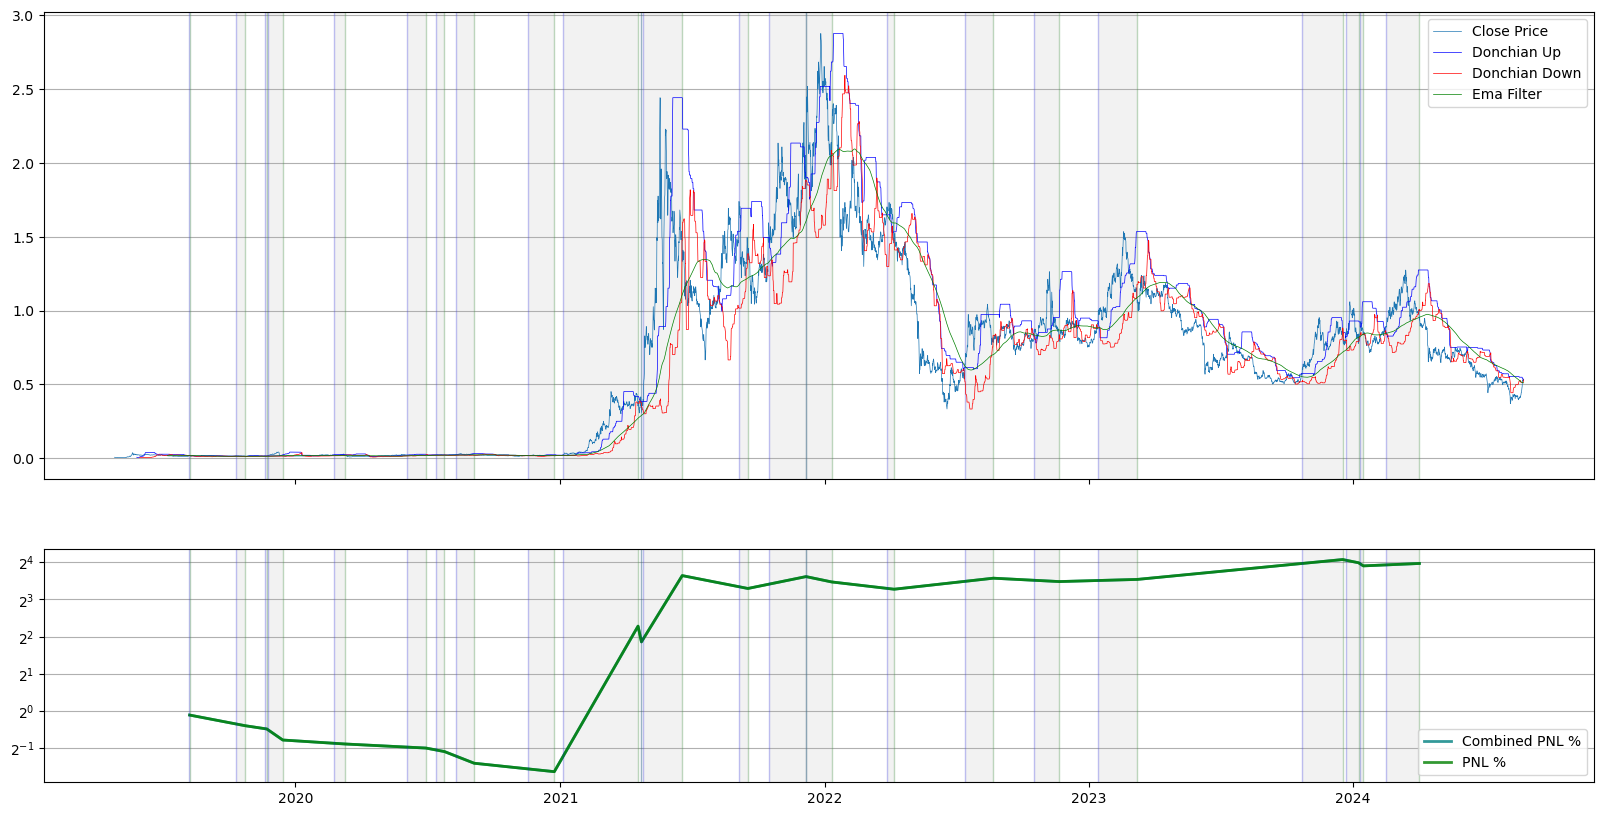

***** binance, EGLD, 8h, 0
Metric                    |           Value
---------------------------------------------
Tot Return                |         26.7794
Max Drawdown              |         -0.4759
N Trades                  |         14.0000
Sharpe Ratio              |          0.3144
Sortino Ratio             |          3.0658
Avg Return                |          0.2680
Max Win                   |         12.5455
Max Loss                  |         -0.2391
Avg Win                   |          1.0399
Avg Loss                  |         -0.1123
Win Ratio                 |          0.4286
Profit Factor             |          4.4880
N Wins                    |          6.0000
N Losses                  |          8.0000
Avg Drawdown              |         -0.1953


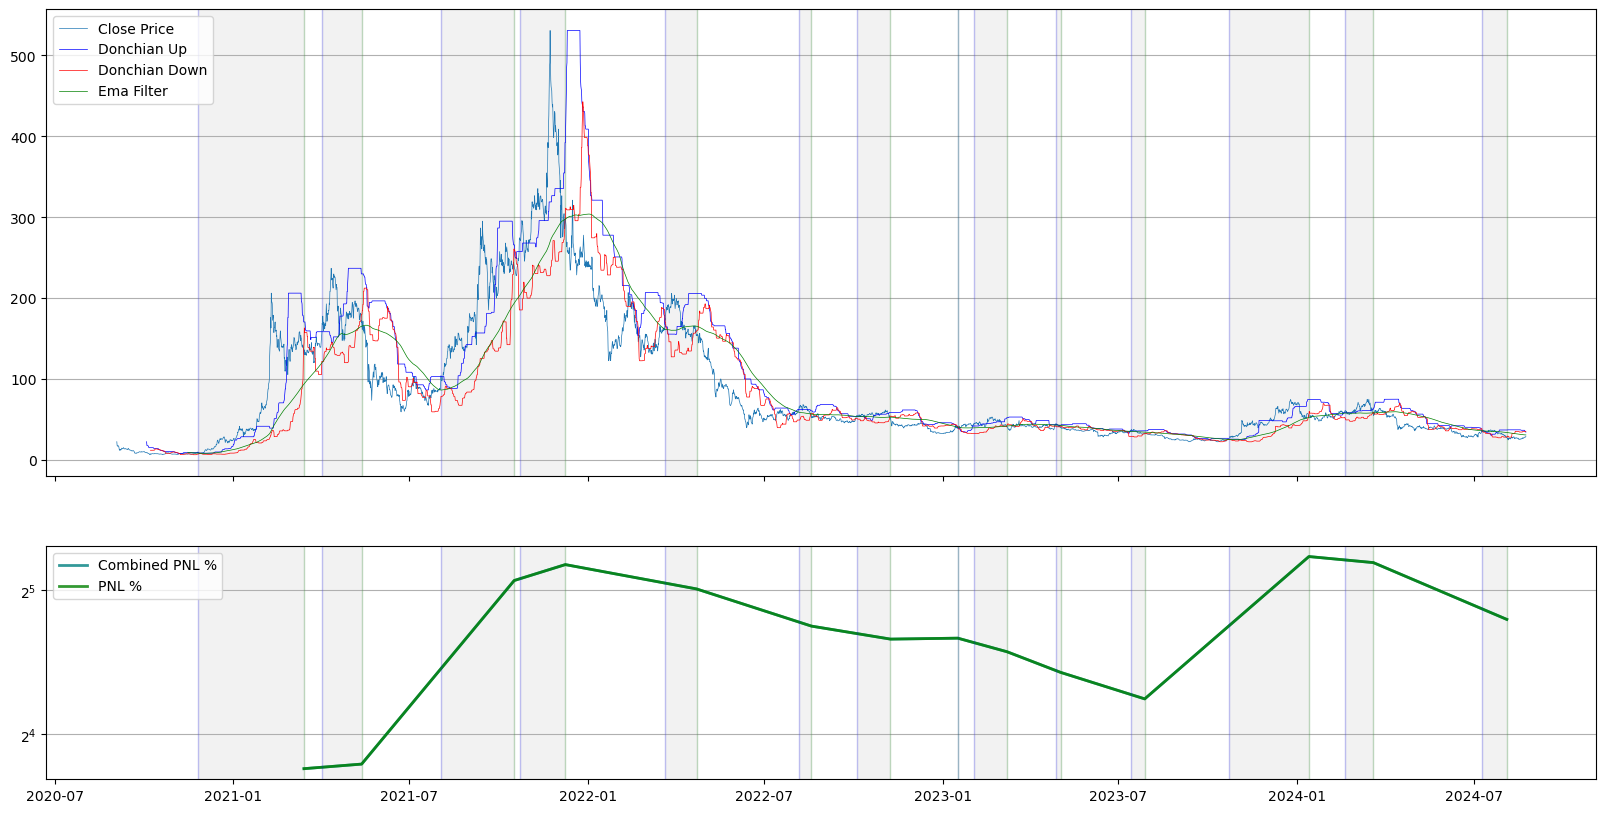

***** binance, VET, 8h, 0
Metric                    |           Value
---------------------------------------------
Tot Return                |         25.4619
Max Drawdown              |         -0.5962
N Trades                  |         23.0000
Sharpe Ratio              |          0.2305
Sortino Ratio             |          1.9927
Avg Return                |          0.1531
Max Win                   |         10.7722
Max Loss                  |         -0.2155
Avg Win                   |          1.0943
Avg Loss                  |         -0.1119
Win Ratio                 |          0.3043
Profit Factor             |          2.7251
N Wins                    |          7.0000
N Losses                  |         16.0000
Avg Drawdown              |         -0.3315


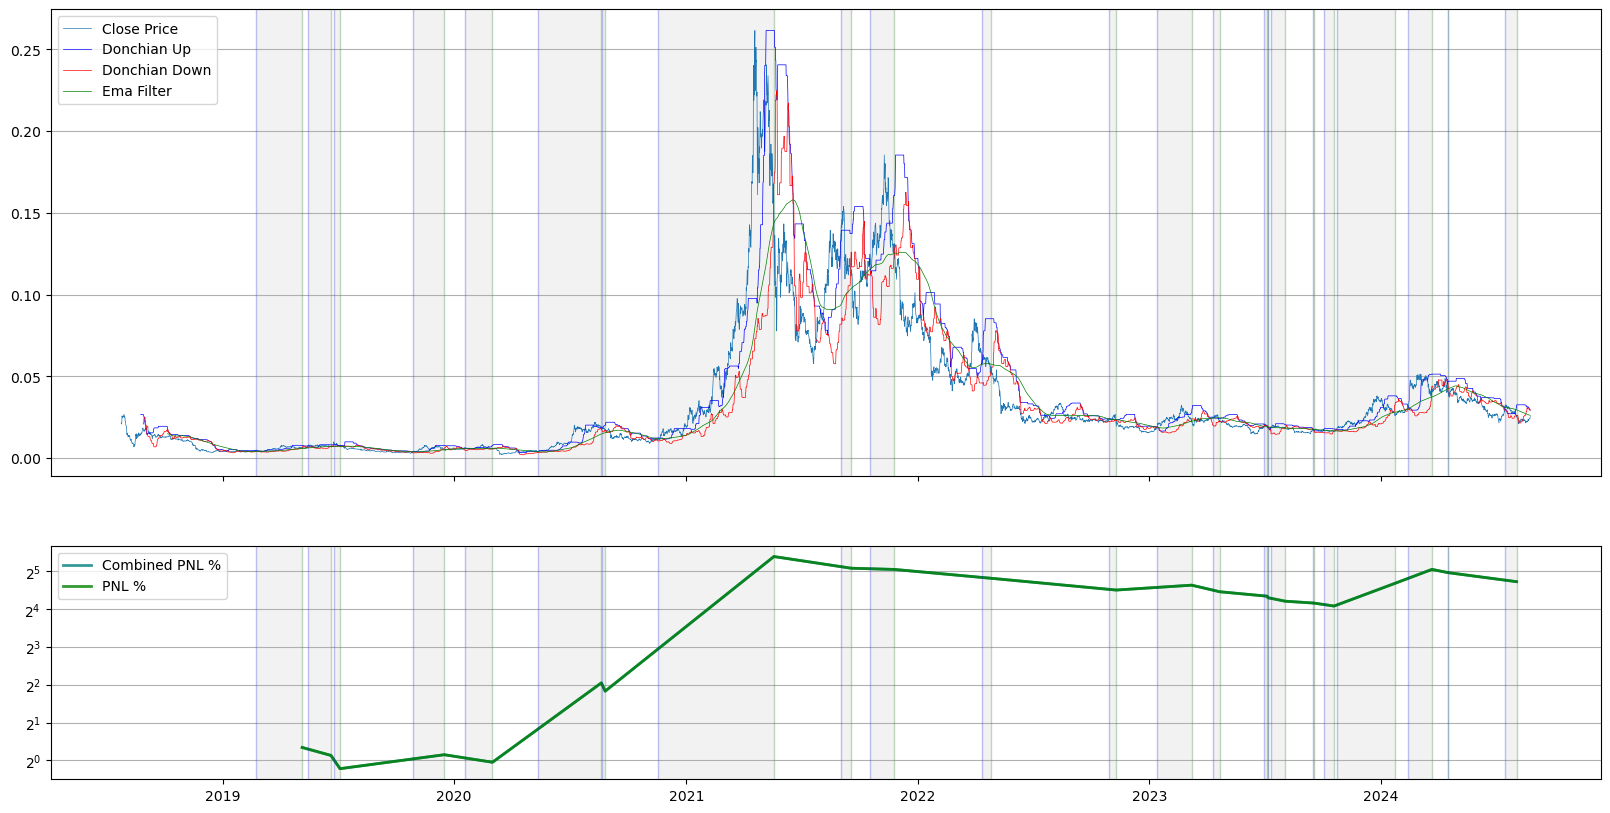

***** binance, THETA, 8h, 0
Metric                    |           Value
---------------------------------------------
Tot Return                |         23.8353
Max Drawdown              |         -0.6371
N Trades                  |         17.0000
Sharpe Ratio              |          0.2708
Sortino Ratio             |          2.8722
Avg Return                |          0.2080
Max Win                   |         12.4656
Max Loss                  |         -0.1841
Avg Win                   |          1.5407
Avg Loss                  |         -0.1138
Win Ratio                 |          0.2941
Profit Factor             |          3.2154
N Wins                    |          5.0000
N Losses                  |         12.0000
Avg Drawdown              |         -0.2899


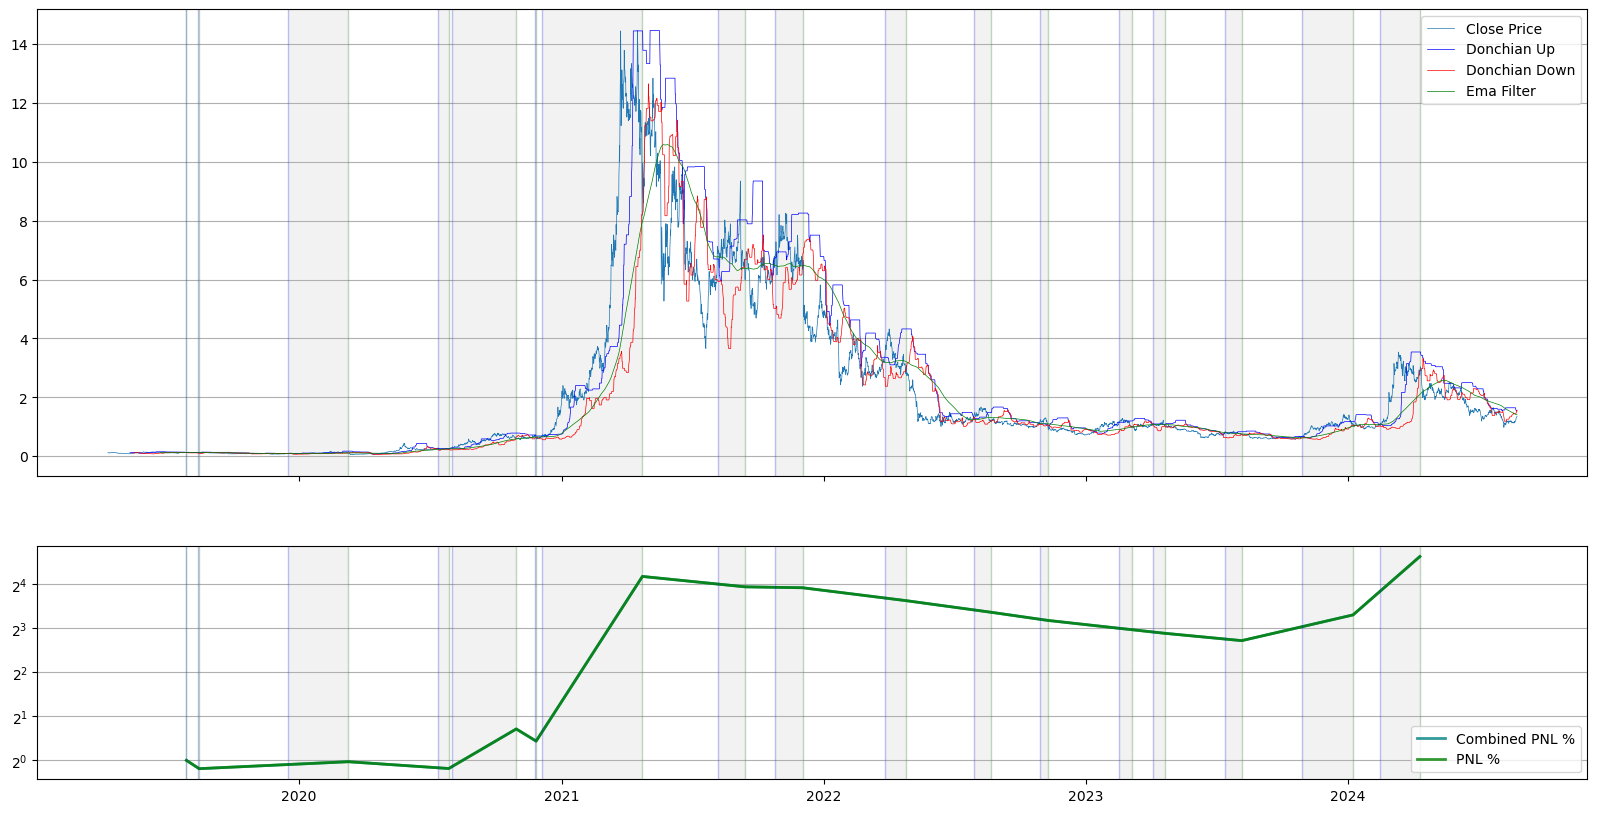

***** binance, CHZ, 8h, 0
Metric                    |           Value
---------------------------------------------
Tot Return                |         15.3451
Max Drawdown              |         -0.5278
N Trades                  |         20.0000
Sharpe Ratio              |          0.1874
Sortino Ratio             |          0.9285
Avg Return                |          0.1499
Max Win                   |         21.5775
Max Loss                  |         -0.3724
Avg Win                   |          0.7059
Avg Loss                  |         -0.1672
Win Ratio                 |          0.4500
Profit Factor             |          2.3882
N Wins                    |          9.0000
N Losses                  |         11.0000
Avg Drawdown              |         -0.2344


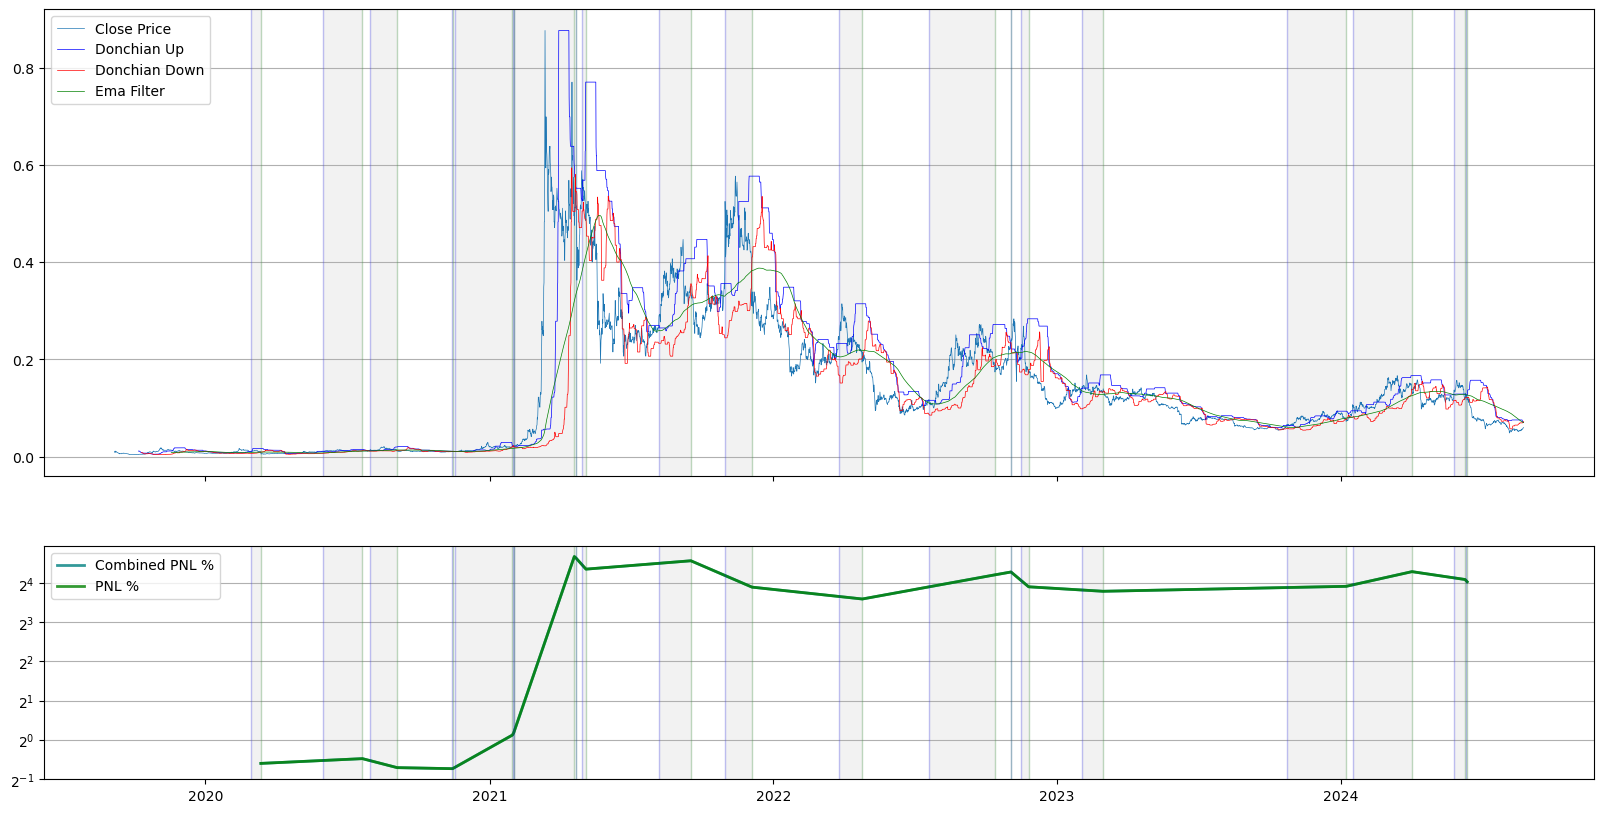

***** kucoin, KCS, 8h, 0
Metric                    |           Value
---------------------------------------------
Tot Return                |         11.3020
Max Drawdown              |         -0.4377
N Trades                  |         26.0000
Sharpe Ratio              |          0.2268
Sortino Ratio             |          1.1472
Avg Return                |          0.1013
Max Win                   |          4.8656
Max Loss                  |         -0.2617
Avg Win                   |          0.5164
Avg Loss                  |         -0.0982
Win Ratio                 |          0.3846
Profit Factor             |          2.5179
N Wins                    |         10.0000
N Losses                  |         16.0000
Avg Drawdown              |         -0.1499


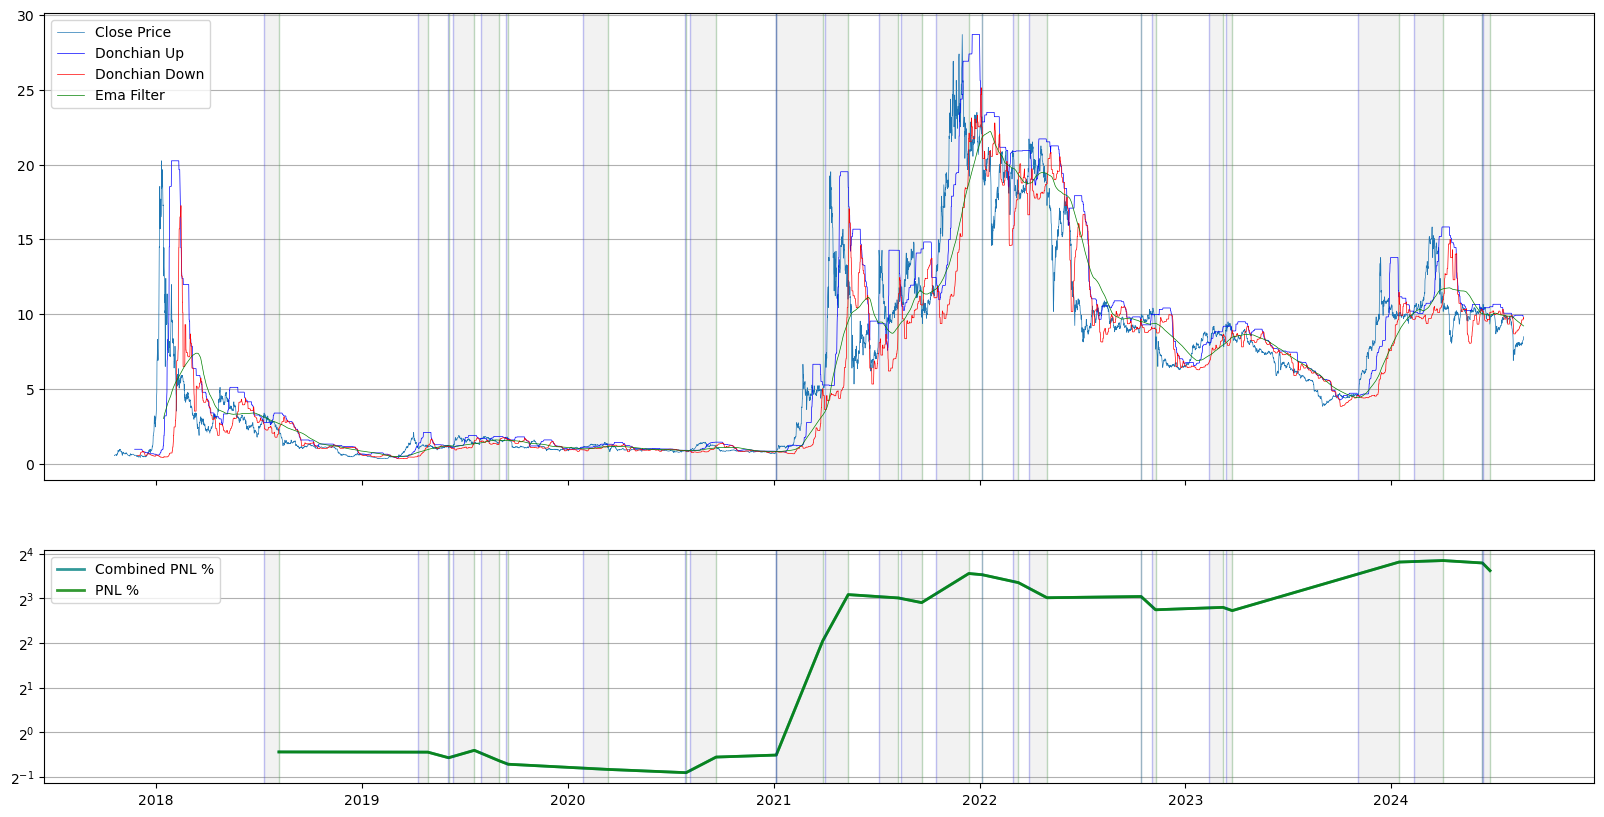

***** binance, ADA, 8h, 0
Metric                    |           Value
---------------------------------------------
Tot Return                |         25.9641
Max Drawdown              |         -0.6101
N Trades                  |         23.0000
Sharpe Ratio              |          0.2615
Sortino Ratio             |          1.2662
Avg Return                |          0.1540
Max Win                   |          8.9117
Max Loss                  |         -0.3339
Avg Win                   |          0.6655
Avg Loss                  |         -0.1297
Win Ratio                 |          0.4348
Profit Factor             |          2.8236
N Wins                    |         10.0000
N Losses                  |         13.0000
Avg Drawdown              |         -0.2729


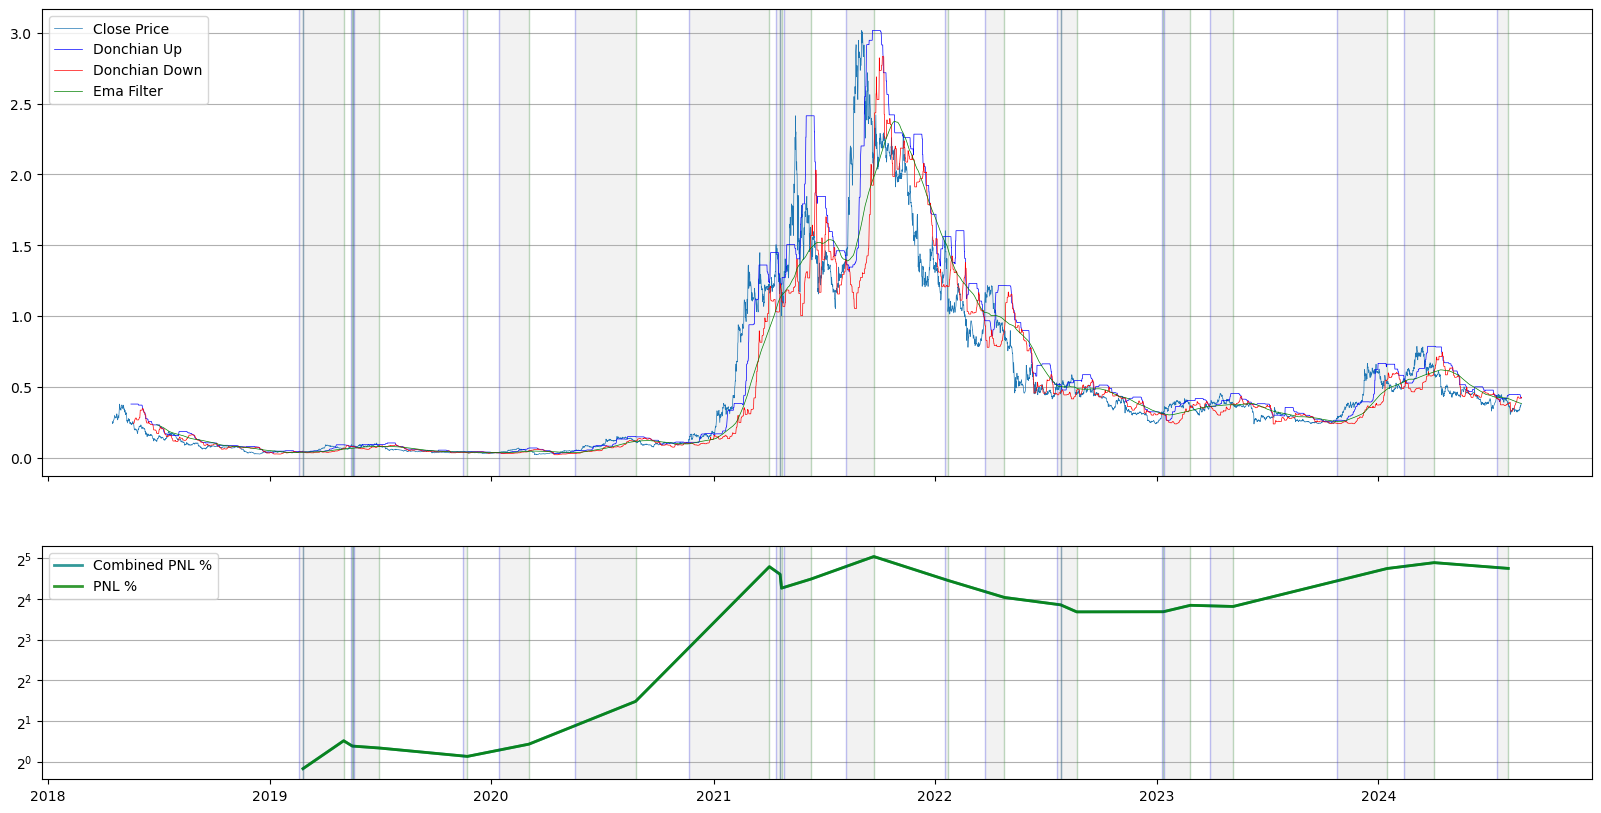

***** binance, BNB, 8h, 0
Metric                    |           Value
---------------------------------------------
Tot Return                |         69.7963
Max Drawdown              |         -0.2743
N Trades                  |         28.0000
Sharpe Ratio              |          0.3087
Sortino Ratio             |          3.8434
Avg Return                |          0.1643
Max Win                   |          6.1357
Max Loss                  |         -0.1549
Avg Win                   |          0.6280
Avg Loss                  |         -0.0627
Win Ratio                 |          0.3929
Profit Factor             |          4.8695
N Wins                    |         11.0000
N Losses                  |         17.0000
Avg Drawdown              |         -0.1033


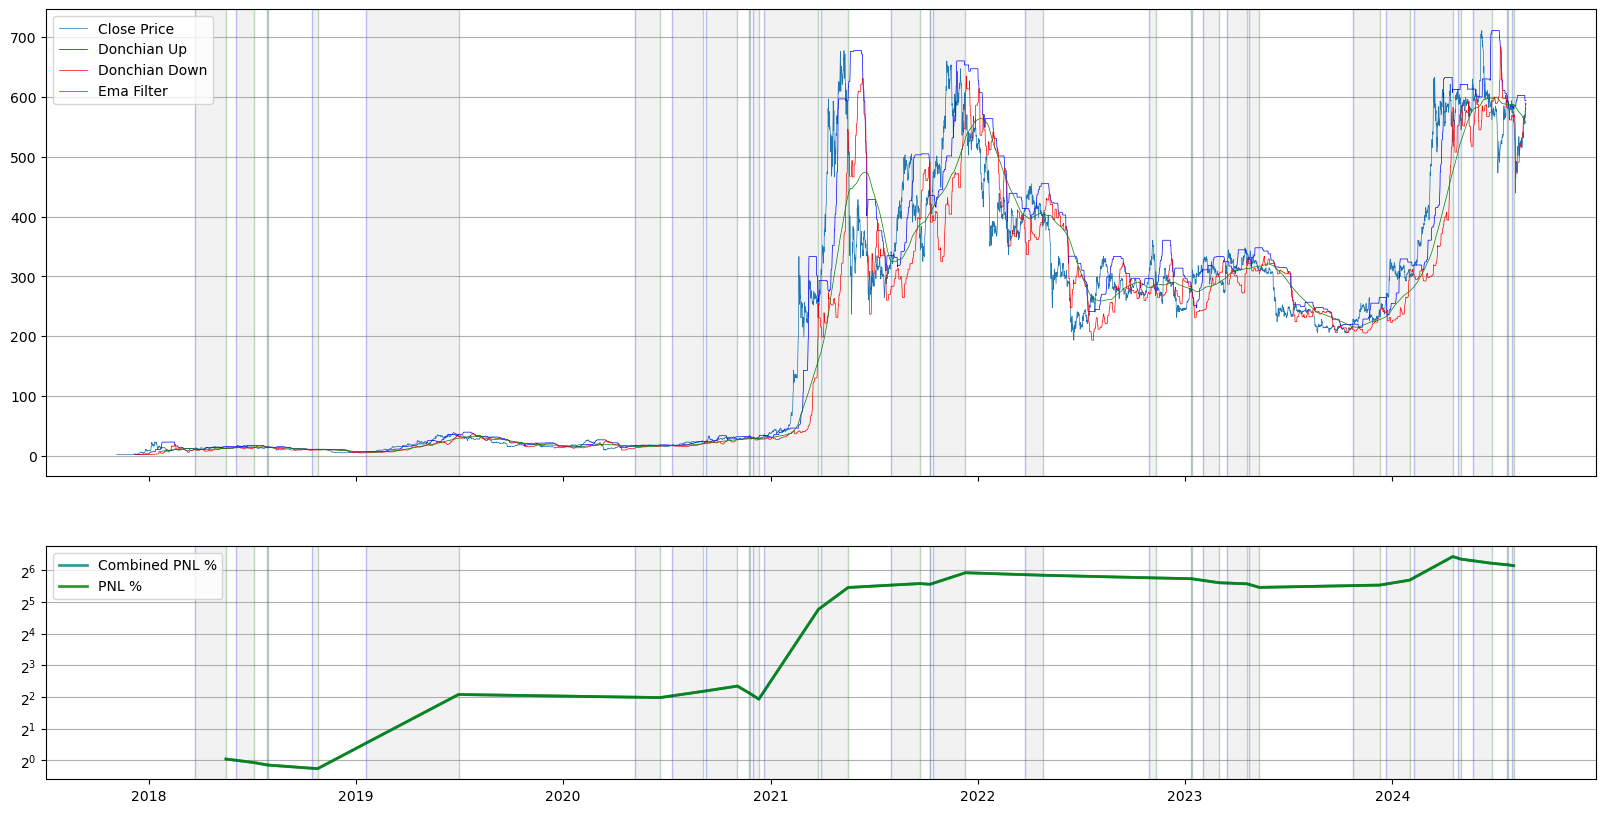

***** binance, ETH, 8h, 0
Metric                    |           Value
---------------------------------------------
Tot Return                |         11.0974
Max Drawdown              |         -0.4058
N Trades                  |         23.0000
Sharpe Ratio              |          0.3176
Sortino Ratio             |          1.0367
Avg Return                |          0.1145
Max Win                   |          3.2639
Max Loss                  |         -0.2565
Avg Win                   |          0.2839
Avg Loss                  |         -0.1057
Win Ratio                 |          0.6087
Profit Factor             |          3.4796
N Wins                    |         14.0000
N Losses                  |          9.0000
Avg Drawdown              |         -0.1051


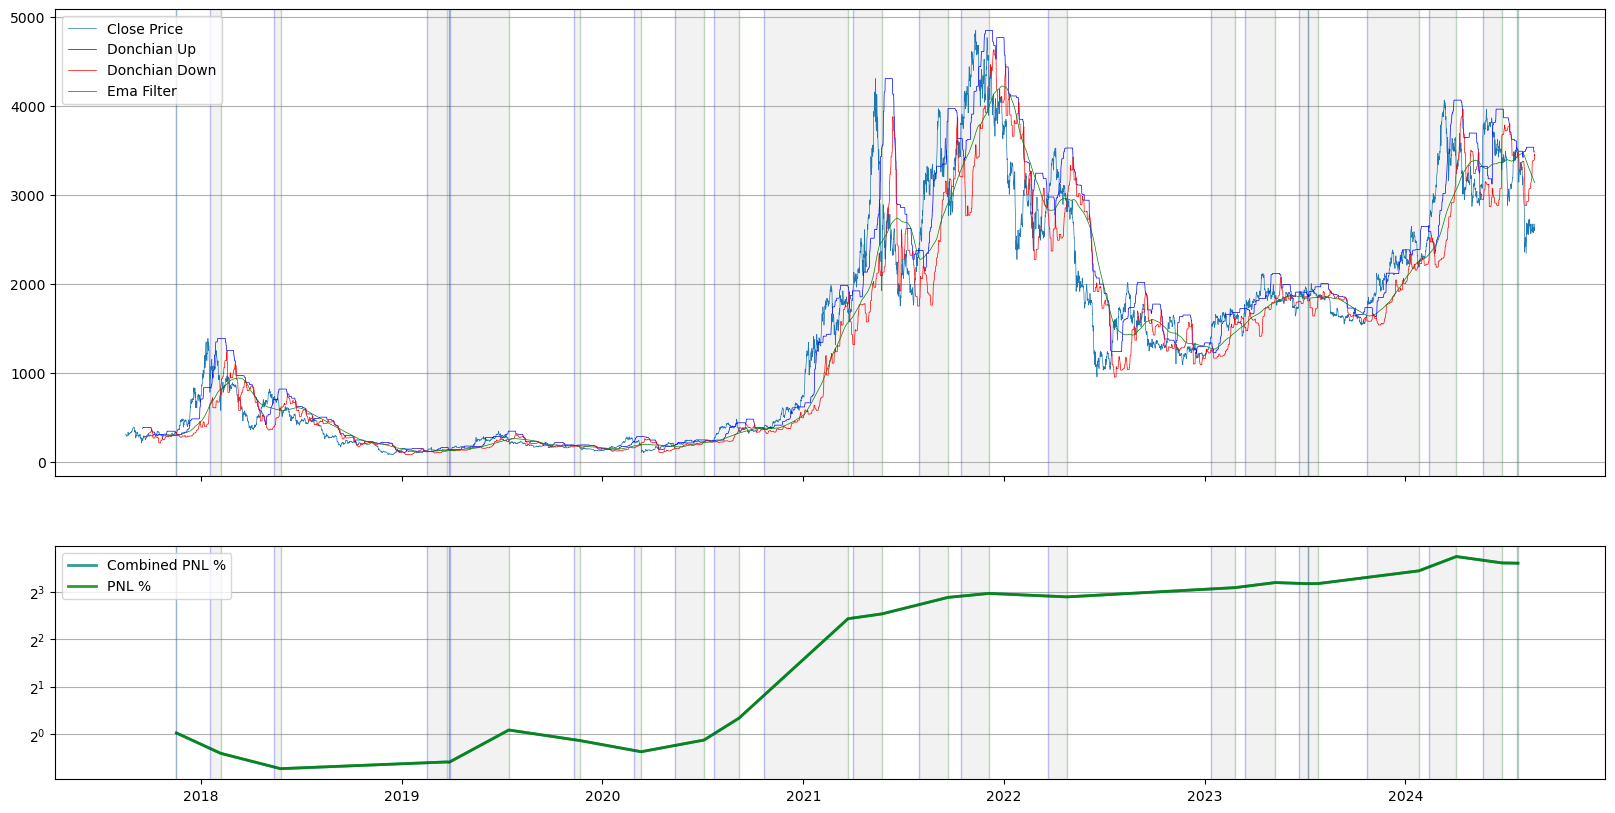

***** kucoin, CRO, 8h, 0
Metric                    |           Value
---------------------------------------------
Tot Return                |         13.6060
Max Drawdown              |         -0.4401
N Trades                  |         11.0000
Sharpe Ratio              |          0.5456
Sortino Ratio             |          5.9711
Avg Return                |          0.2760
Max Win                   |          2.2544
Max Loss                  |         -0.1397
Avg Win                   |          0.9199
Avg Loss                  |         -0.0921
Win Ratio                 |          0.4545
Profit Factor             |          5.6229
N Wins                    |          5.0000
N Losses                  |          6.0000
Avg Drawdown              |         -0.1845


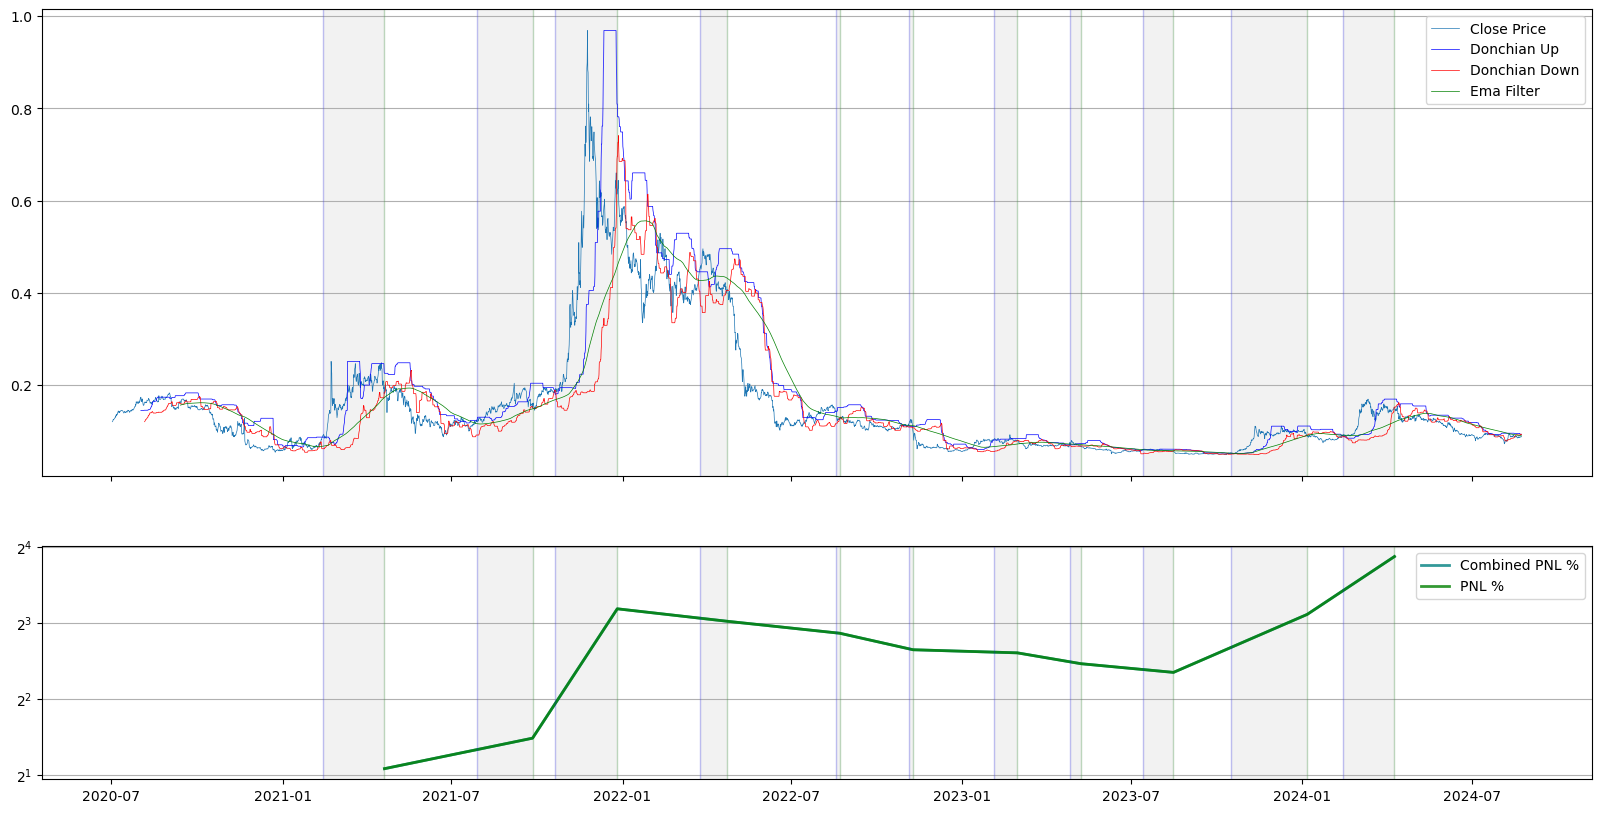

***** kucoin, BTT, 8h, 0
Metric                    |           Value
---------------------------------------------
Tot Return                |         14.0111
Max Drawdown              |         -0.4246
N Trades                  |         18.0000
Sharpe Ratio              |          0.2180
Sortino Ratio             |          2.9123
Avg Return                |          0.1624
Max Win                   |         16.6844
Max Loss                  |         -0.1305
Avg Win                   |          0.8177
Avg Loss                  |         -0.0704
Win Ratio                 |          0.3333
Profit Factor             |          4.0899
N Wins                    |          6.0000
N Losses                  |         12.0000
Avg Drawdown              |         -0.2096


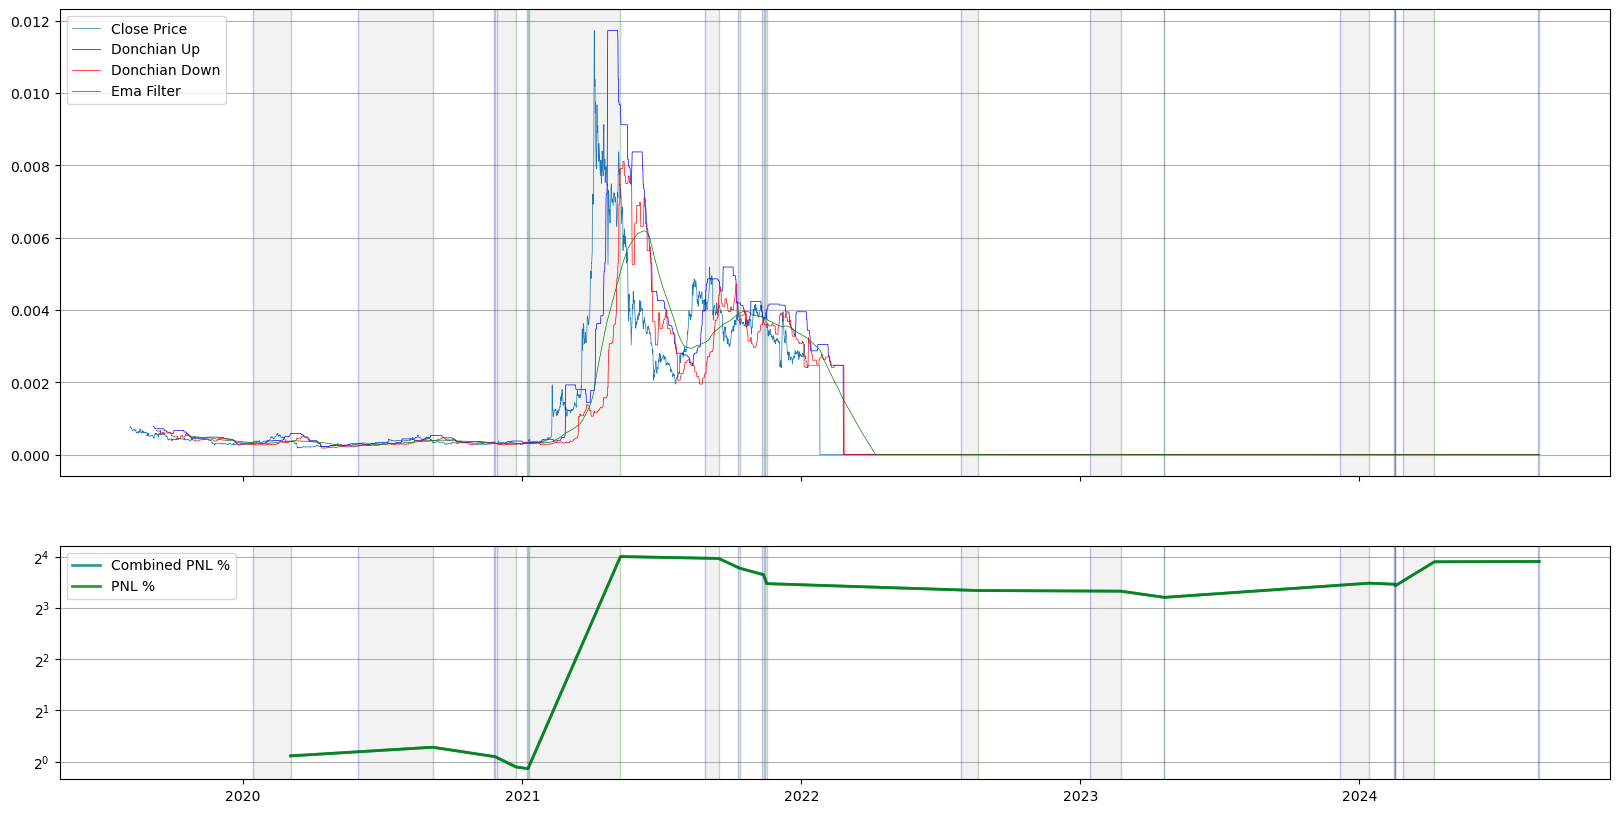

***** binance, STX, 8h, 0
Metric                    |           Value
---------------------------------------------
Tot Return                |          7.1131
Max Drawdown              |         -0.7367
N Trades                  |         20.0000
Sharpe Ratio              |          0.2038
Sortino Ratio             |          0.8611
Avg Return                |          0.1103
Max Win                   |          2.1409
Max Loss                  |         -0.4093
Avg Win                   |          0.7857
Avg Loss                  |         -0.1911
Win Ratio                 |          0.4000
Profit Factor             |          1.8226
N Wins                    |          8.0000
N Losses                  |         12.0000
Avg Drawdown              |         -0.2894


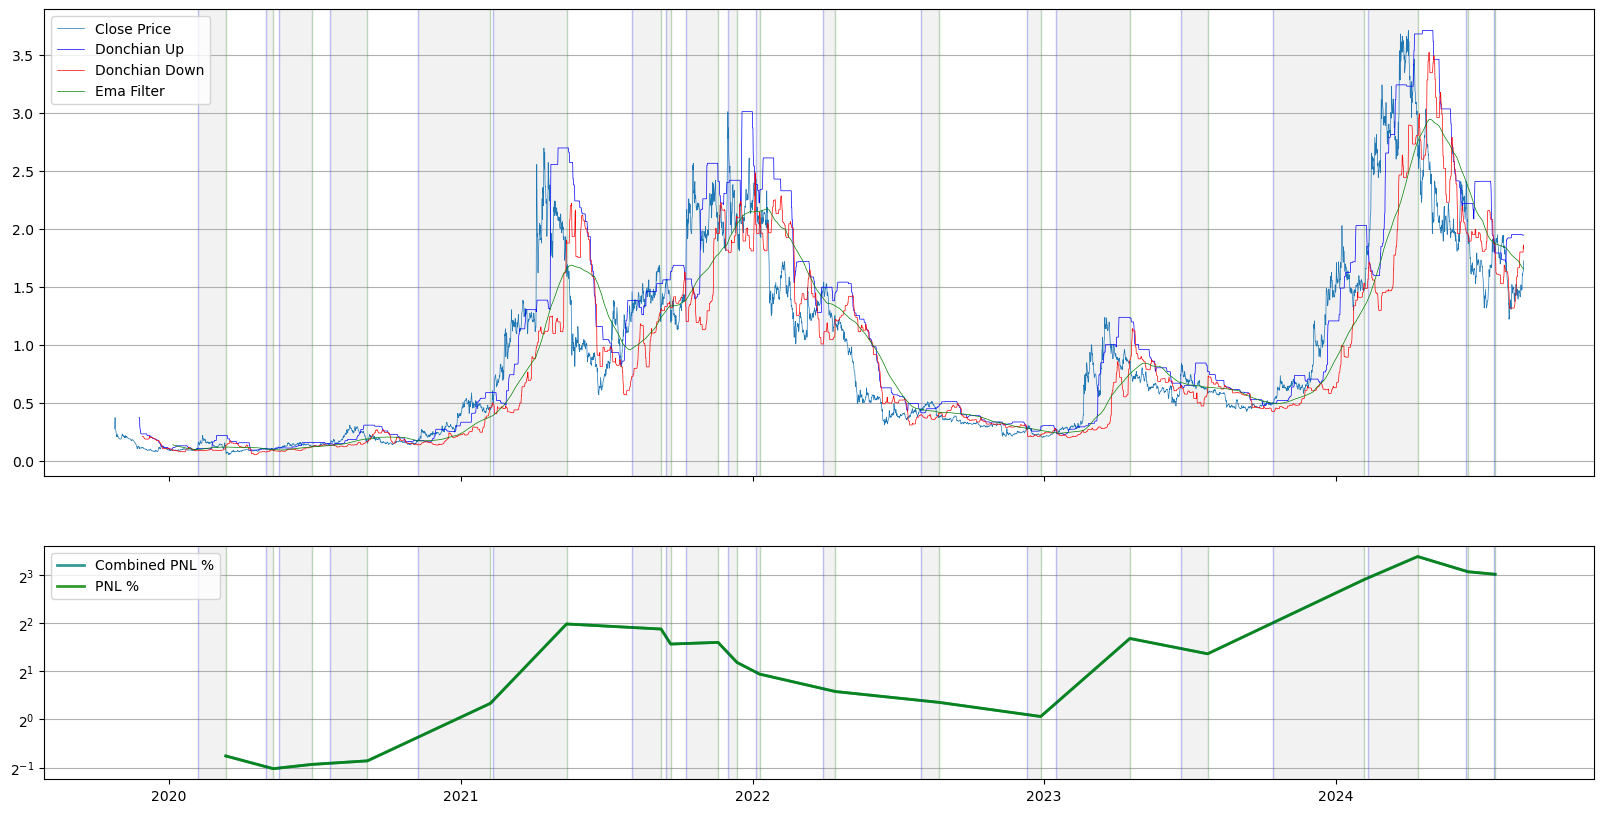

***** binance, ROSE, 8h, 0
Metric                    |           Value
---------------------------------------------
Tot Return                |         11.5316
Max Drawdown              |         -0.4437
N Trades                  |         12.0000
Sharpe Ratio              |          0.4737
Sortino Ratio             |          3.4424
Avg Return                |          0.2345
Max Win                   |          1.7820
Max Loss                  |         -0.1601
Avg Win                   |          0.7074
Avg Loss                  |         -0.1074
Win Ratio                 |          0.5000
Profit Factor             |          4.7100
N Wins                    |          6.0000
N Losses                  |          6.0000
Avg Drawdown              |         -0.1905


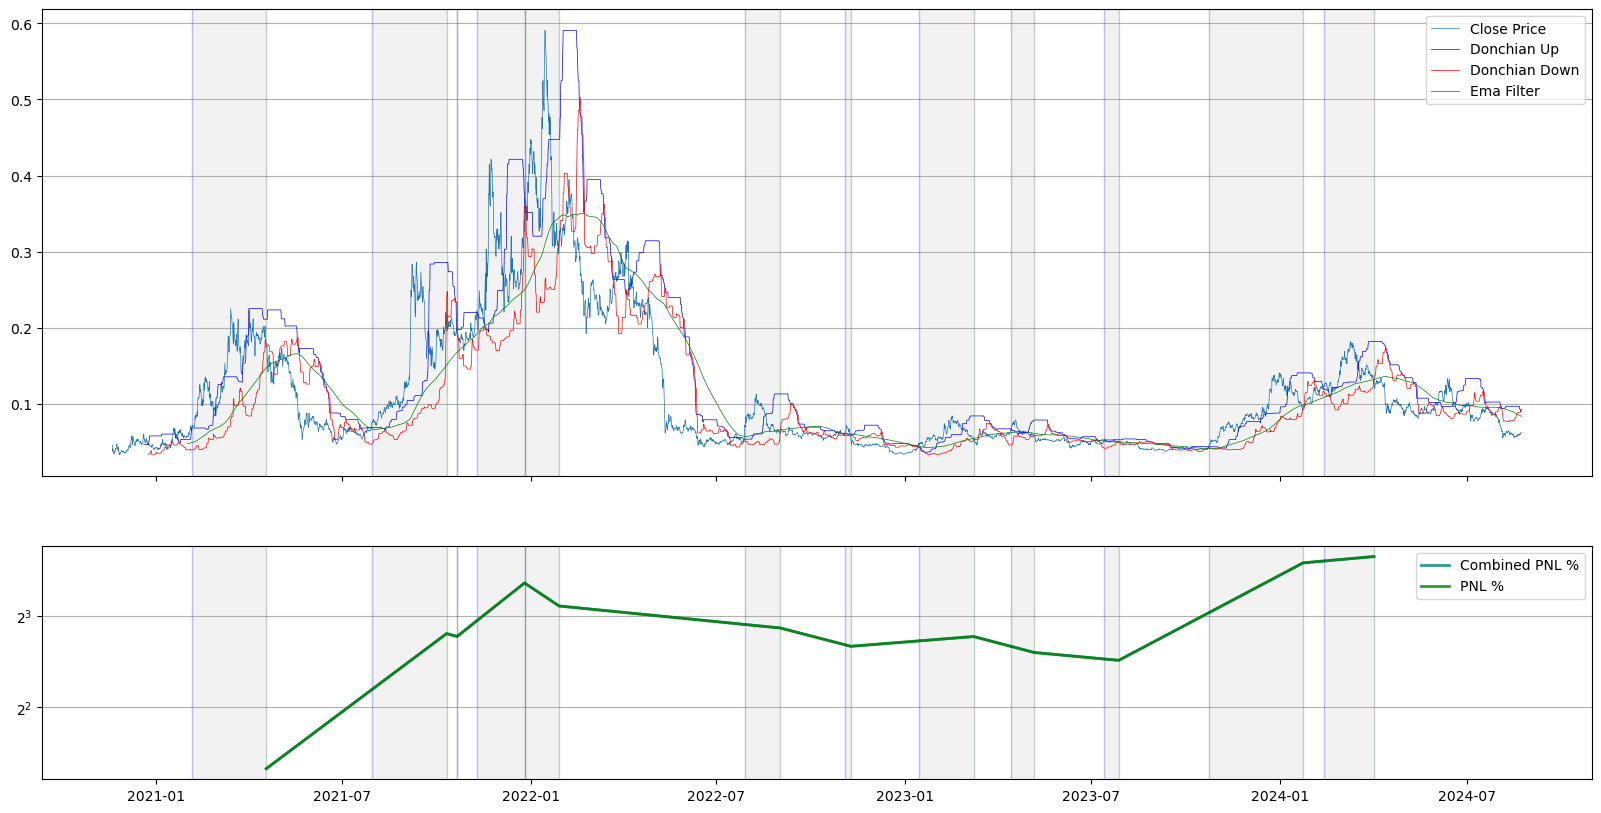

***** binance, MANA, 8h, 0
Metric                    |           Value
---------------------------------------------
Tot Return                |         11.4751
Max Drawdown              |         -0.5295
N Trades                  |         12.0000
Sharpe Ratio              |          0.3167
Sortino Ratio             |          3.0524
Avg Return                |          0.2341
Max Win                   |          6.3619
Max Loss                  |         -0.2045
Avg Win                   |          1.4289
Avg Loss                  |         -0.1204
Win Ratio                 |          0.3333
Profit Factor             |          3.4596
N Wins                    |          4.0000
N Losses                  |          8.0000
Avg Drawdown              |         -0.2537


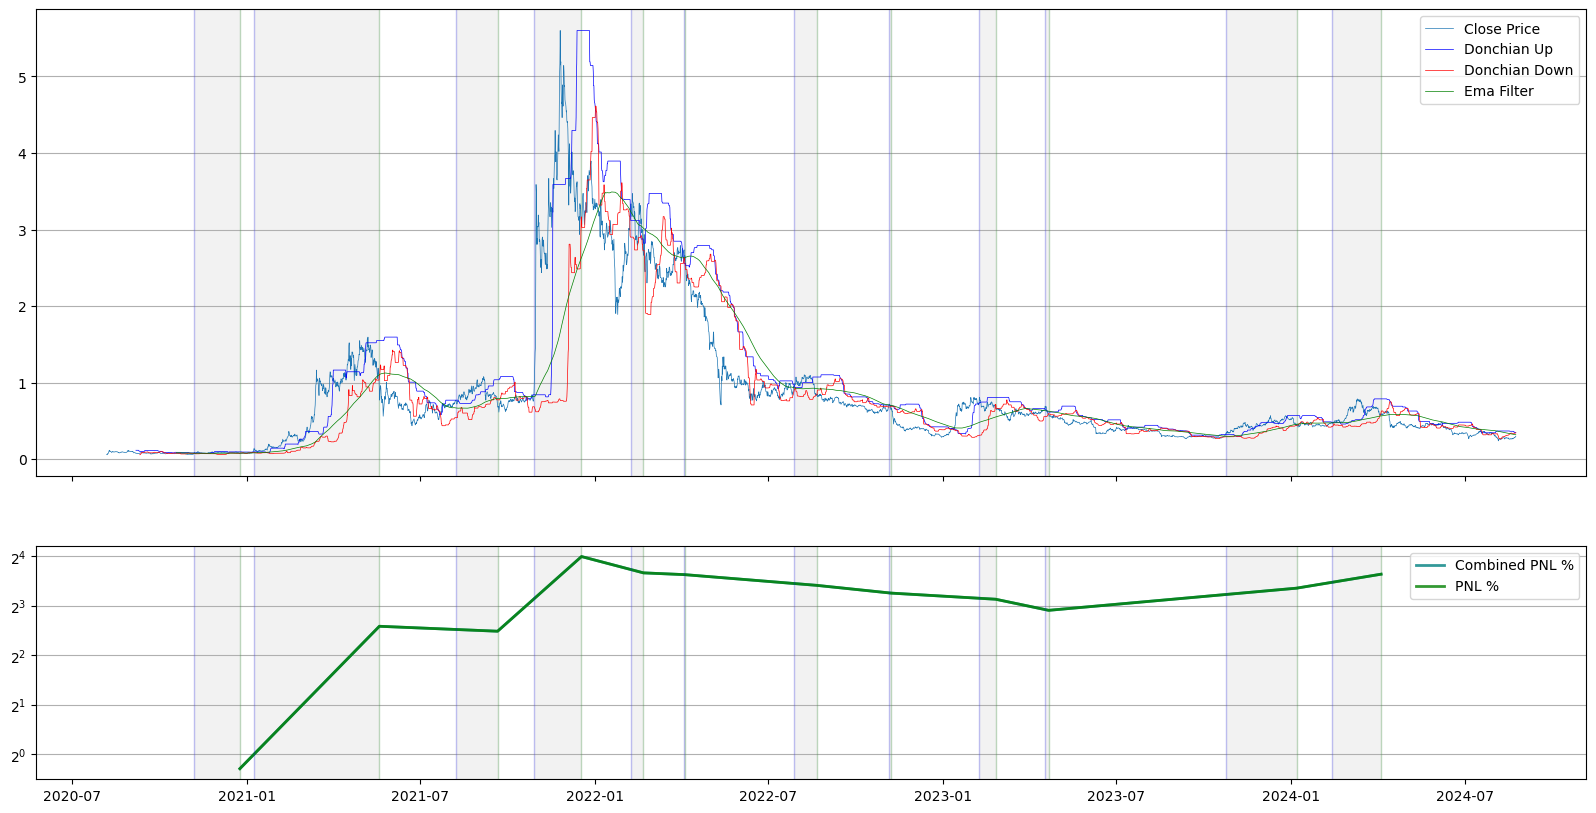

***** binance, SHIB, 8h, 0
Metric                    |           Value
---------------------------------------------
Tot Return                |         11.1470
Max Drawdown              |         -0.3933
N Trades                  |         14.0000
Sharpe Ratio              |          0.3183
Sortino Ratio             |          3.3374
Avg Return                |          0.1953
Max Win                   |          4.9834
Max Loss                  |         -0.1445
Avg Win                   |          0.7323
Avg Loss                  |         -0.0951
Win Ratio                 |          0.4286
Profit Factor             |          4.1235
N Wins                    |          6.0000
N Losses                  |          8.0000
Avg Drawdown              |         -0.1723


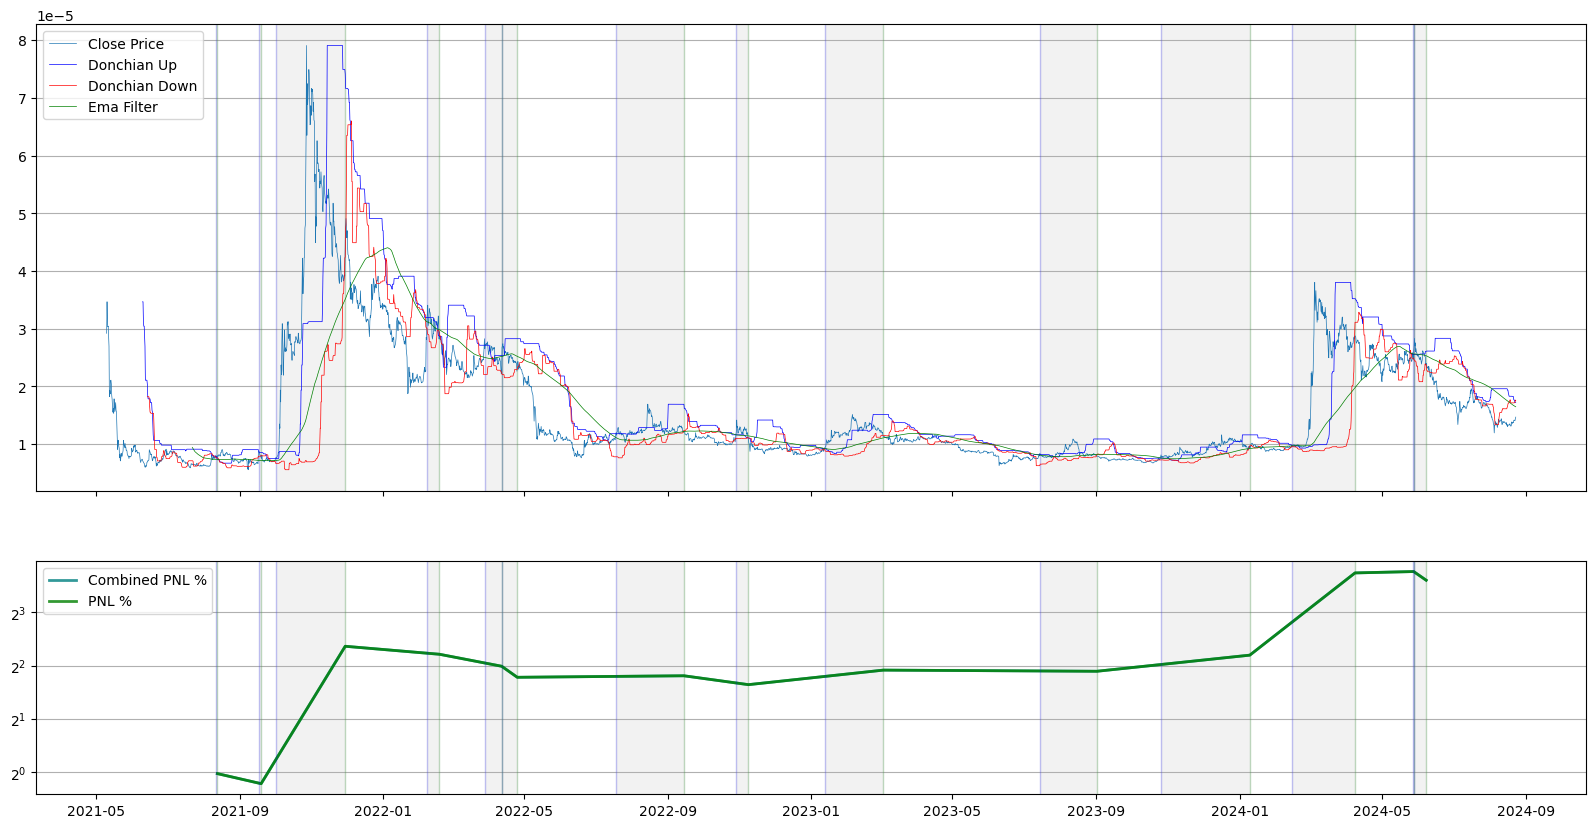

***** binance, NEAR, 8h, 0
Metric                    |           Value
---------------------------------------------
Tot Return                |         10.0677
Max Drawdown              |         -0.3260
N Trades                  |         12.0000
Sharpe Ratio              |          0.3837
Sortino Ratio             |          2.8488
Avg Return                |          0.2218
Max Win                   |          3.7688
Max Loss                  |         -0.2029
Avg Win                   |          0.6813
Avg Loss                  |         -0.1121
Win Ratio                 |          0.5000
Profit Factor             |          4.3694
N Wins                    |          6.0000
N Losses                  |          6.0000
Avg Drawdown              |         -0.1291


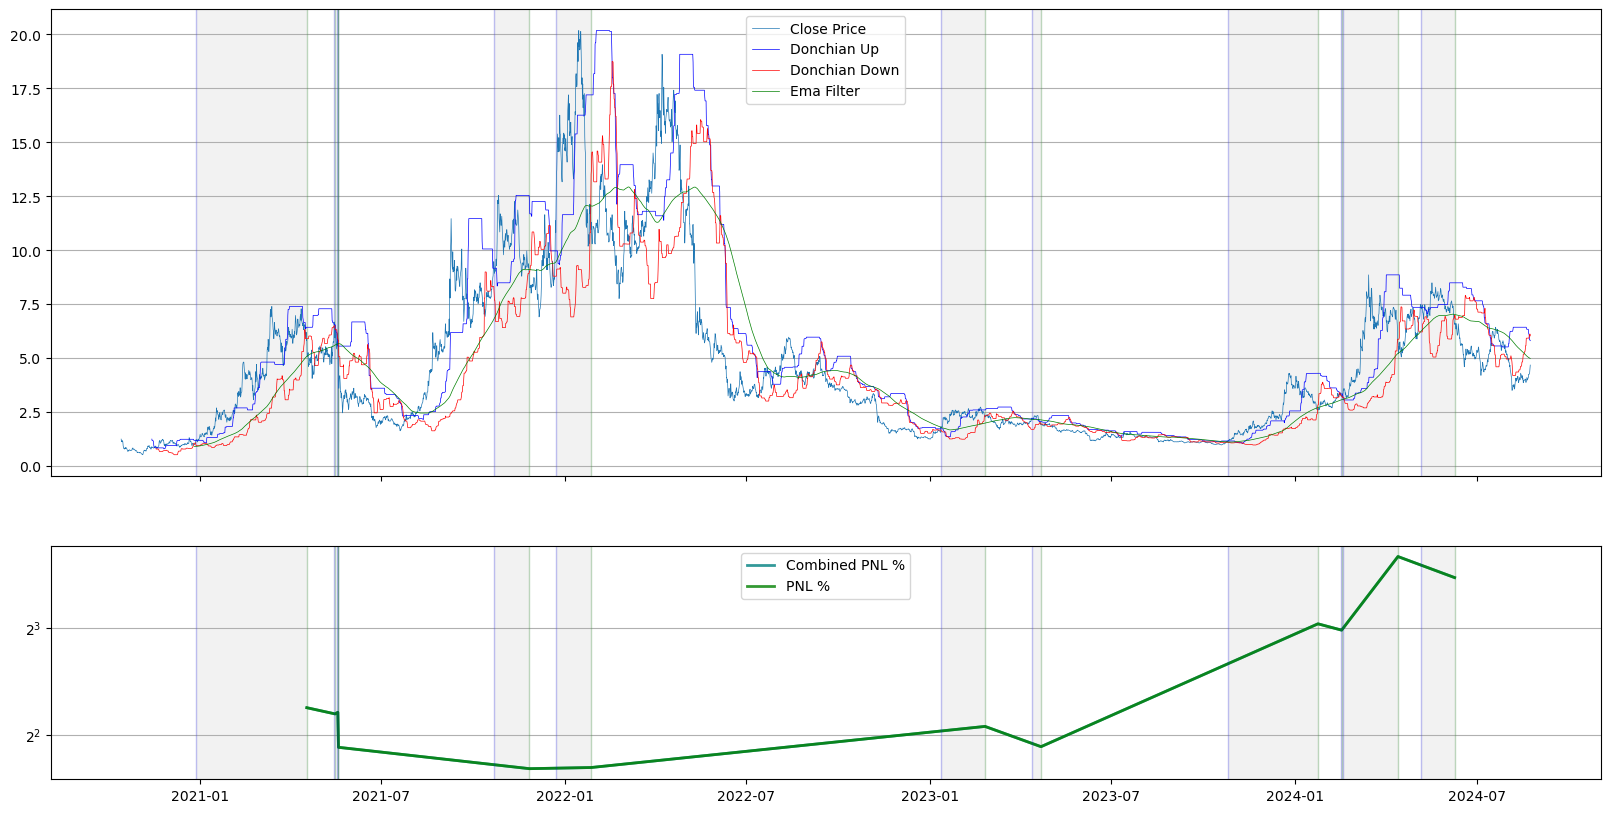

In [96]:
sdf = df[(df.tot_return >= 10)]
for exchange, asset, tfr, ipa in sdf[['exchange','asset','tfr','ipa']].values:
    print(f"====================================================")
    print(f'***** {exchange}, {asset}, {tfr}, {ipa}')
    data = load_candles(exchange,asset, quote, timeframe)#['2020':'2025']#.iloc[-35000:-5000]
    entry_indices, exit_indices, metrics = comp_backtest(data,params,indicators,generate_indicators,generate_bull_signal)
    plot_strategy(data,metrics,entry_indices,exit_indices,plot_indicators)

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

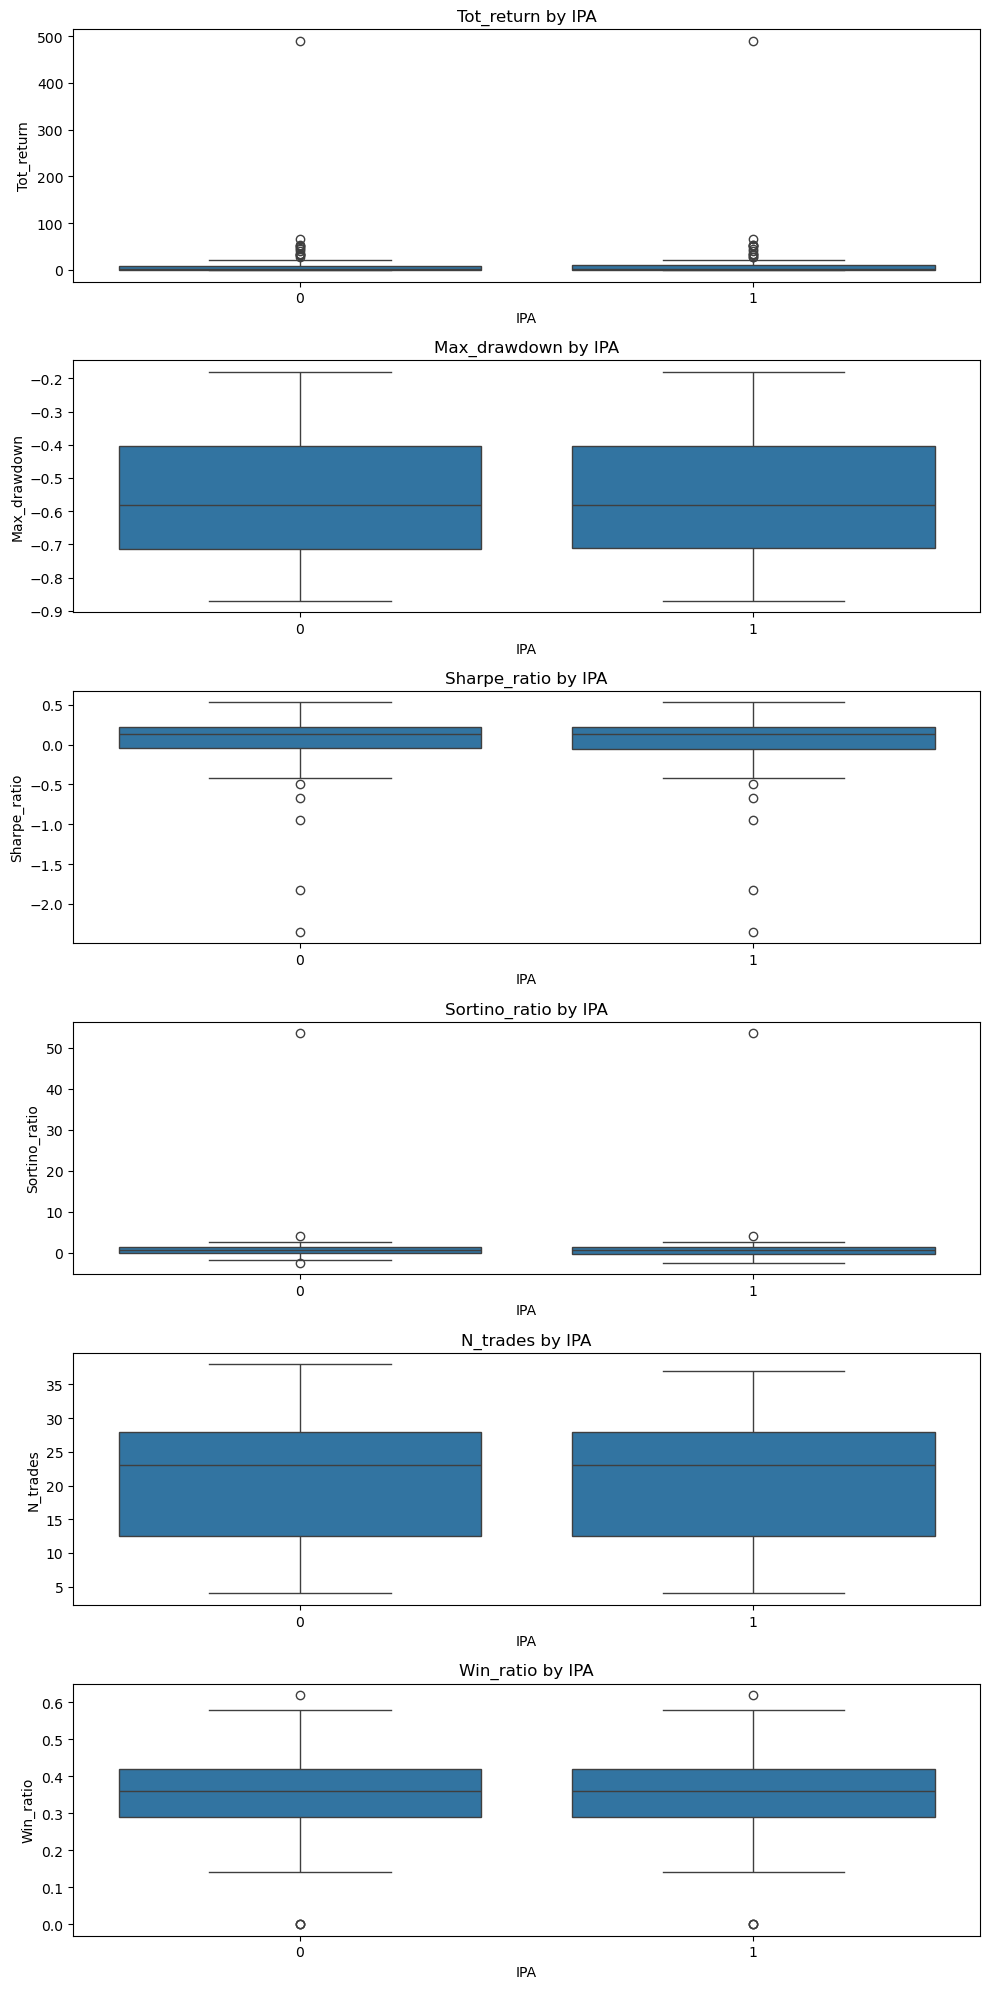

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Metrics to plot
metrics_to_plot = ['tot_return', 'max_drawdown', 'sharpe_ratio', 'sortino_ratio', 'n_trades', 'win_ratio']

# Set up the matplotlib figure
fig, axes = plt.subplots(len(metrics_to_plot), 1, figsize=(10, 20))

# Generate a box plot for each metric grouped by 'ipa'
for i, metric in enumerate(metrics_to_plot):
    sns.boxplot(x='ipa', y=metric, data=df, ax=axes[i])
    axes[i].set_title(f'{metric.capitalize()} by IPA')
    axes[i].set_xlabel('IPA')
    axes[i].set_ylabel(metric.capitalize())

plt.tight_layout()
plt.show()


In [ ]:
for ix, exchange, asset, ipa, tfr in df[['exchange','asset','ipa','tfr']].to_records():
    print(f'=========  {asset}  /  {ipa}  /  {tfr}  ===============================')
    data = load_candles(exchange,asset,quote,tfr)#['2021':]
    fig_tr,res_tr = plot_performance(data,asset,params, indicators=indicators, enable_short=True, signals=signals, reset_index=False, btkwargs={'xmult':1, 'slippage': 0.005, 'transaction_cost': 0.001, 'period_costs': 0.0003/6}, title=f'TRAIN DATA: [0:{data.shape[0]}]')

In [ ]:
[c for c in df.columns if c[0] not in ['long_metrics','short_metrics','overall_metrics'] or c[1] in ['tot_return','max_drawdown'] ]


## Randomize params and assets, test for robustness

In [ ]:
timeframe,quote,nhours ='1h', 'USDT', 4
# np.random.seed = 3
opt_backtests = [backtest(load_candles(asset_exch_dict[asset], asset, quote,timeframe)['2021':].resample(f'{nhours}H').agg( {'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'}),params,nhours=nhours,short_long=[-1,1],xmult=1) for (asset, params) in list(zip(df_opt.index,np.random.permutation(df_opt['params'].values))) ]


In [ ]:

rand_backtests = pd.DataFrame([{k:v for (k,v) in opt_bt.items() if not (isinstance(v,pd.Series) or isinstance(v,pd.Index)  or isinstance(v,np.ndarray))} for opt_bt in opt_backtests], index=df_pfexch.index)
rand_backtests.sort_values('tot_return').tail()

In [ ]:
rand_backtests[['tot_return_pct','trade_max_drawdown_pct']].describe()


In [ ]:
rand_backtests.hist(bins=50,figsize=(20,8))
plt.tight_layout()

## Simulate 100 randomized parameter set picks

In [ ]:
## Run a bunch of randomized simulations
timeframe,quote,nhours ='1h', 'USDT', 8
ran_sumul = []
for i in tqdm(range(10)):
    opt_backtests = [backtest(load_candles(asset_exch_dict[asset], asset, quote,timeframe)['2021':].resample(f'{nhours}H').agg( {'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'}),params,nhours=nhours,short_long=[1],xmult=1) for (asset, params) in list(zip(df_opt.index,np.random.permutation(df_opt['params'].values))) ]
    ran_backtests = pd.DataFrame([{k:v for (k,v) in opt_bt.items() if not (isinstance(v,pd.Series) or isinstance(v,pd.Index)  or isinstance(v,np.ndarray))} for opt_bt in opt_backtests], index=df_pfexch.index)
    ran_sumul.append(ran_backtests[['tot_return_pct','trade_max_drawdown_pct']].describe().to_dict())
    
# np.histogram(ran_sumul)


In [ ]:
ran_sumul
# pd.DataFrame.from_records(ran_sumul)
# simul_rets = pd.Series(ran_sumul)
# simul_rets.describe(),simul_rets.hist(bins=50)

In [ ]:

opt_backtests = [print_performance(load_candles(asset_exch_dict[asset], asset, quote,timeframe)['2021':],nhours,params,backtest,short_long=[-1,1],xmult=1) for (asset, params) in list(zip(df_opt.index,np.random.permutation(df_opt['params'].values))) ]

## Generate pinescript for a bunch of assets

In [ ]:
assets = ['ADA', 'ALGO', 'DOT', 'LINK', 'SOL']
exchange = 'BINANCE'
def objective(trial):
    global data
    up_lookback = trial.suggest_int('up_lookback', 7, 100)
    dn_lookback = trial.suggest_int('dn_lookback', 7, 100)
    up_lag = trial.suggest_int('up_lag', 7, 100)
    dn_lag = trial.suggest_int('dn_lag', 7, 100)
    params = {
        'up_lookback': up_lookback,
        'dn_lookback': dn_lookback,
        'up_lag': up_lag,
        'dn_lag': dn_lag
    }
    res = backtest(data,params,nhours,short_long, xmult=1)
    return res['tot_return'], res['trade_max_drawdown']#/ math.cos(number_of_trades)
nhours = 1
# data = data.resample(f'{nhours}H').agg( {'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'})
short_long = [1]
asset_params = {}
for asset in assets:
    data = load_candles('binance',asset,'USDT','8h')#['2011':'2025']#.iloc[-10000:]
    # Run the optimization
    study = optuna.create_study(directions=['maximize','maximize'])
    study.optimize(objective, n_trials=100)
    asset_params[f'{asset}USDT'] = study.best_trials[-1].params

In [ ]:
asset_params

In [ ]:
from jinja2 import Template
quote = 'USDT'
# Define the template (could also be loaded from a .jinja2 file)
template_str = """
//@version=5
indicator("Custom Donchian with Asset-Specific Parameters", overlay=true)

up_lag = 20
up_lookback = 20
dn_lag = 20
dn_lookback = 20
split_string = str.split(ticker.standard(),":")
string tkr = split_string.last()
// Determine parameters based on asset
{% for asset, params in asset_params.items() %}
if (tkr == "{{ asset }}{{ quote }}")
    up_lag := {{ params.up_lag }}
    dn_lag := {{ params.dn_lag }}
    up_lookback := {{ params.up_lookback }}
    dn_lookback := {{ params.dn_lookback }}
{% endfor %}

// Upper Donchian Band: Highest high over the up_lookback period, shifted by donch_up periods
upper_band = ta.highest(high, up_lookback)[up_lag]
// Lower Donchian Band: Lowest low over the dn_lookback period, shifted by donch_dn periods
lower_band = ta.lowest(low, dn_lookback)[dn_lag]
// Middle line between the upper and lower bands
middle_line = (upper_band + lower_band) / 2

// Plotting the upper and lower bands
plot(upper_band, title="Upper Donchian Band", color=color.green, linewidth=2)
plot(lower_band, title="Lower Donchian Band", color=color.red, linewidth=2)
plot(middle_line, title="Middle Line", color=color.gray, linewidth=2)

"""

template_str2 = """
bla
{% for asset in assets %}
 "{{ asset }}"
{% endfor %}
"""
# Create a template object
template = Template(template_str)

# Render the template with the asset_params dictionary
rendered_pine_script = template.render(asset_params=asset_params, quote=quote)

# Output the generated Pine Script
print(rendered_pine_script)



## Split data into training and testing set

In [ ]:
np.min([params[k] for k in params])

In [ ]:

data = load_candles('binance','BTC','USDT','1h')#.iloc[-5000:]
# data = load_futures_candles('bybit','ALGO','USDT','1h')['2020-03':'2025']
# data = data['2021-11-01':].copy()
nhours = 8
data = data.resample(f'{nhours}H').agg( {'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'})
short_long = [-1,1]

train_ratio = 0.3; 
cutoff = int(train_ratio * data.shape[0])
train_data, test_data = data.iloc[:cutoff,:], data.iloc[cutoff+1-np.max([params[k] for k in params]):,:]

study = optimize(train_data, nhours,backtest_fn=backtest, short_long=short_long)
params = study.best_params
params = {'tenkan_period': 19, 'kijun_period': 22, 'senkou_span_b_period': 22}
print(f'params = {params}')
print_performance(test_data,nhours,params,backtest_fn=backtest,short_long=short_long, xmult=1)
print_performance(train_data,nhours,params,backtest_fn=backtest,short_long=short_long, xmult=1)
print(f'params = {params}')

In [ ]:
train_data

## Backtest in a LOOP

In [ ]:
   
def backtest(data, nhours, short_long=None, xmult=1):
    if short_long is None: short_long = [1,-1]

    # Initialize the 'position' column
    data['position'] = 0
    
    # # Set the 'position' column based on the signals
    if 1 in short_long:
        data.loc[data['bull'], 'position'] = 1        
        data.loc[(data['bull'] & data['bull_exit']), 'position'] = 0   
    # Exit position when exit signal is True
    
    # Set the 'position' column based on the signals
    if -1 in short_long:
        data.loc[(data['bear']), 'position'] = -1    
        data.loc[(data['bear'] & data['bear_exit']), 'position'] = 0
    ###    
    # data['position'] = xmult*(int(1 in short_long) * (data['bull'] &~ data['bull_exit'])) - (int(-1 in short_long) * (data['bear'] &~ data['bear_exit']))
    positions_shifted = data['position'].shift()#.fillna(0).astype(int)
    data['trade'] = data['position'].diff()#.fillna(0).astype(int)
    data.at[data.index[-1],'trade'] = -data.iloc[-1]['position']
    data['strategy_returns'] = positions_shifted * (data['lclose'].diff().fillna(0))
    number_of_trades = data['trade'].abs().sum()
    data['strategy_returns'] -= data['trade'].abs() * (transaction_cost + slippage)
    data['cumulative_returns'] = data['strategy_returns'].cumsum()
    
    data['pct_strategy_returns'] = np.exp(data['strategy_returns']) -1
    data['pct_cumulative_returns'] = np.exp(data['cumulative_returns']) -1
    ###
    
    
    # Apply transaction costs and slippage only on trades
    # data['strategy_returns'] -= data['trade'] * (transaction_cost + slippage)

    
    # Calculate performance metrics
    total_return = data['pct_cumulative_returns'].iloc[-1]
    annualized_return = data['pct_strategy_returns'].mean() * 365 * 24 / 8  # Assuming 8-hour bars
    annualized_volatility = data['pct_strategy_returns'].std() * np.sqrt(365 * 24 / nhours)
    sharpe_ratio = annualized_return / annualized_volatility
    

## Forward Testing

In [ ]:
# data = load_futures_candles('bybit','ADA','USDT','1h')['2020':'2023']
data = load_candles('binance','BTC','USDT','1h')['2020':'2025']
ohlc_dict = {'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'}
nhours = 8 ; ntrain = 3 ; ndays = 30
short_long = [1]
data = data.resample(f'{nhours}H').agg(ohlc_dict)#[:'2022']
n = data.shape[0]
w = (24 // nhours) * ndays
fwd_params = []
for i in tqdm(range(ntrain, (n // w)-1)):
    fwd_params.append(optimize(data.iloc[(i-ntrain)*w:(i)*w-1], nhours, short_long=short_long,xmult=1).best_params)
    

In [ ]:
df_params = pd.DataFrame(fwd_params)
df_params.describe()

In [ ]:


bt_arr = []; res_arr =[]
for i in tqdm(range(ntrain, (n // w)-1)):    
    # print(i)
    wdata = indicators(data.iloc[i*w:(i+1)*w],fwd_params[i-ntrain])
    results = backtest(wdata,nhours,short_long)
    decorate_trades(wdata)
    bt_arr.append(wdata)
    res_arr.append(results)

In [ ]:
data.shape[0], w, i, i*w, (i+1)*w

In [ ]:
df_res = pd.DataFrame(res_arr)
df_res#.describe()

In [ ]:
df_res.sharpe_ratio.mean(), (1+df_res.total_return).cumprod().values[-1], df_res.number_of_trades.sum()

In [ ]:
df_trd = pd.concat(bt_arr)
ax = df_trd['pct_strategy_returns'].add(1).cumprod().subtract(1).plot()
# df_trd['pct_cumulative_returns'].plot(ax=ax)

In [ ]:
df_trd

In [ ]:
data = load_candles('ALGO','USDT','1h')['2022-06':]

ohlc_dict = {
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum'
}

data = data.resample(f'{8}H').agg(ohlc_dict)
# data = data['2021-11-01':].copy()
short_long = [-1,1]
study = optimize(data, short_long=short_long)
best_params = study.best_params
# best_params = {'ema_fast_len': 8, 'ema_slow_len': 100, 'ema_margin_atr_len': 45, 'ema_margin_atr_mult': 2.3369417327913116}

print(f'best_params= {best_params}')
# window = data['2024-01':'2025-01'].index
window = None
print_performance(data,best_params,window=window,short_long=short_long)
print(f'Best params: {best_params}')

## Test different Timeframes with resampling

In [ ]:
data = load_candles('ALGO','USDT','1h')#['2021-04':]
ohlc_dict = {
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum'
}
test_results = []
short_long=[-1,1]
resample_periods = np.arange(5,100,1)
for i in tqdm(resample_periods, desc="Processing"):
    rdata = data.resample(f'{i}H').agg(ohlc_dict)
    study = optimize(rdata, short_long=short_long)
    test_results.append(study)


In [ ]:
# data = load_candles('PEPE','USDT','2h')#['2021-04':]
rparams = [study.best_params for study in test_results]
rbacktests = []
short_long=[-1,1]
for i in tqdm(range(len(resample_periods))):
    rdata = data.iloc[5:].resample(f'{resample_periods[i]}H').agg(ohlc_dict)
    params = test_results[i].best_params
    rdata = indicators(rdata, params)
    test_result = backtest(rdata, short_long)
    decorate_trades(rdata)
    rbacktests.append(test_result)
    

             
# [(resample_periods[i],rbacktests[i][1]) for i in range(len(rbacktests))]

In [ ]:

suffixes = ['_suffix', '_suffix2']

# Function to remove suffixes from a key
def remove_suffixes(key, suffixes):
    for suffix in suffixes:
        if key.endswith(suffix):
            return key[:-len(suffix)]
    return key

# Function to remove the suffixes from dictionary keys
def remove_suffixes_from_dict(d, suffixes):
    return {remove_suffixes(key, suffixes): value for key, value in d.items()}

dfres = pd.DataFrame([{'period': i, 'days':int(i*2/24),  **(remove_suffixes_from_dict(d1.best_params, ['_len'])), **d2} for i, d1, d2 in zip(resample_periods,test_results, rbacktests)])

dfres.head(10)

dfres.sort_values(by='total_return', axis=0, ascending=False).head(10)

In [ ]:
data = load_candles('ALGO','USDT','1h')['2022-06':]

ohlc_dict = {
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum'
}
i = 6
data = data.resample(f'{resample_periods[i]}H').agg(ohlc_dict)
# data = data['2021-11-01':].copy()
short_long = [-1]
study = optimize(data, short_long=short_long)
best_params = study.best_params
# best_params = {'ema_fast_len': 8, 'ema_slow_len': 100, 'ema_margin_atr_len': 45, 'ema_margin_atr_mult': 2.3369417327913116}

print(f'best_params= {best_params}')
# window = data['2024-01':'2025-01'].index
window = None
print_performance(data,best_params,window=window,short_long=short_long)
print(f'Best params: {best_params}')

In [ ]:

# Calculate Ichimoku Cloud components
def ichimoku_cloud_log(data, tenkan_period=9, kijun_period=26, senkou_span_b_period=52):
    data['tenkan_sen'] = data['close'].rolling(window=tenkan_period).mean()
    data['kijun_sen'] = data['close'].rolling(window=kijun_period).mean()
    data['senkou_span_a'] = ((data['tenkan_sen'] + data['kijun_sen']) / 2).shift(kijun_period)
    data['senkou_span_b'] = data['close'].rolling(window=senkou_span_b_period).mean().shift(kijun_period)
    return data.dropna()

# Define trading signals
def ichimoku_trading_signals(data):
    buy_signals = (data['tenkan_sen'] > data['kijun_sen']) & \
                  (data['close'] > data['senkou_span_a']) & \
                  (data['close'] > data['kijun_sen']) & \
                  (data['close'] > data['senkou_span_b'])

    sell_signals = (data['close'] < data['senkou_span_a']) | \
                   (data['close'] < data['senkou_span_b'])

    return buy_signals.shift(1).fillna(False), sell_signals.shift(1).fillna(False)

# Fully vectorized backtest without holding period
def fully_vectorized_backtest_no_holding_period(data, buy_signals, sell_signals):
    position = np.zeros(len(data))
    returns = np.ones(len(data))

    for i in range(1, len(data)):
        if buy_signals.iloc[i] and position[i - 1] == 0:
            position[i] = 1  # Buy signal, enter position
        elif position[i - 1] > 0:
            position[i] = 1  # Maintain position

            if sell_signals.iloc[i]:
                returns[i] = data['close'].iloc[i] / data['close'].iloc[np.where(position[:i])[0][-1]]  # Calculate return
                position[i] = 0  # Exit position
        else:
            returns[i] = 1  # No trade, no return

    cumulative_returns = pd.Series(np.cumprod(returns), index=data.index)
    return cumulative_returns

# Genetic Algorithm for parameter optimization
def genetic_algorithm(num_generations, population_size, num_parents):
    # Define the parameter space
    tenkan_range = (5, 30)
    kijun_range = (20, 60)
    senkou_span_b_range = (40, 120)

    # Initialize population
    def initialize_population(size):
        population = []
        for _ in range(size):
            individual = [
                np.random.randint(*tenkan_range),
                np.random.randint(*kijun_range),
                np.random.randint(*senkou_span_b_range)
            ]
            population.append(individual)
        return population

    # Fitness function
    def fitness_function(individual):
        tenkan_period, kijun_period, senkou_span_b_period = individual
        temp_data = ichimoku_cloud_log(data.copy(), tenkan_period, kijun_period, senkou_span_b_period)
        buy_signals, sell_signals = ichimoku_trading_signals(temp_data)
        cumulative_returns = fully_vectorized_backtest_no_holding_period(temp_data, buy_signals, sell_signals)
        final_cumulative_return = cumulative_returns.iloc[-1]
        return final_cumulative_return

    # Selection
    def select_parents(population, fitnesses, num_parents):
        normalized_fitnesses = np.array(fitnesses) / np.sum(fitnesses)
        parents = np.random.choice(np.arange(len(population)), size=num_parents, replace=False, p=normalized_fitnesses)
        return [population[parent] for parent in parents]

    # Crossover
    def crossover(parents):
        offspring = []
        for i in range(0, len(parents), 2):
            parent1 = parents[i]
            parent2 = parents[(i + 1) % len(parents)]
            crossover_point = np.random.randint(1, len(parent1))
            child1 = parent1[:crossover_point] + parent2[crossover_point:]
            child2 = parent2[:crossover_point] + parent1[crossover_point:]
            offspring.extend([child1, child2])
        return offspring

    # Mutation
    def mutate(offspring):
        for individual in offspring:
            if np.random.rand() < 0.1:
                mutation_point = np.random.randint(len(individual))
                if mutation_point == 0:
                    individual[mutation_point] = np.random.randint(*tenkan_range)
                elif mutation_point == 1:
                    individual[mutation_point] = np.random.randint(*kijun_range)
                elif mutation_point == 2:
                    individual[mutation_point] = np.random.randint(*senkou_span_b_range)
        return offspring

    # Genetic Algorithm
    population = initialize_population(population_size)
    best_individual = None
    best_fitness = -float('inf')

    for generation in range(num_generations):
        with ThreadPoolExecutor() as executor:
            fitnesses = list(executor.map(fitness_function, population))
        best_generation_fitness = max(fitnesses)
        best_generation_individual = population[fitnesses.index(best_generation_fitness)]
        
        if best_generation_fitness > best_fitness:
            best_fitness = best_generation_fitness
            best_individual = best_generation_individual
        
        if generation % 2 == 0 or generation == num_generations - 1:
            print(f"Generation {generation}: Best Fitness = {best_fitness}")
        
        parents = select_parents(population, fitnesses, num_parents)
        offspring = crossover(parents)
        offspring = mutate(offspring)
        population = parents + offspring

    return best_individual, best_fitness

# Run the genetic algorithm
best_signal_params_ga, best_cumulative_return_signal_ga = genetic_algorithm(num_generations=10, population_size=10, num_parents=5)
print(f"Best Parameters: {best_signal_params_ga}, Best Cumulative Return: {best_cumulative_return_signal_ga}")

# Apply the optimized parameters to the strategy
optimized_data_ga = ichimoku_cloud_log(data.copy(), best_signal_params_ga[0], best_signal_params_ga[1], best_signal_params_ga[2])
buy_signals, sell_signals = ichimoku_trading_signals(optimized_data_ga)

# Apply the optimized backtest strategy without holding period
cumulative_returns_optimized_ga = fully_vectorized_backtest_no_holding_period(optimized_data_ga, buy_signals, sell_signals)

# Plot the cumulative returns
plt.figure(figsize=(12, 6))
plt.plot(cumulative_returns_optimized_ga, label='Cumulative Returns (Optimized Buy Signals)')
plt.title('Ichimoku Trading Strategy Cumulative Returns (Optimized Buy Signals)')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.legend()
plt.show()

# Calculate risk metrics
def calculate_risk_metrics(cumulative_returns):
    returns = cumulative_returns.pct_change().dropna()
    sharpe_ratio = returns.mean() / returns.std() * np.sqrt(252 * 24 / 8)
    max_drawdown = (cumulative_returns / cumulative_returns.cummax() - 1).min()
    return sharpe_ratio, max_drawdown

sharpe_ratio, max_drawdown = calculate_risk_metrics(cumulative_returns_optimized_ga)
print(f"Sharpe Ratio: {sharpe_ratio}, Max Drawdown: {max_drawdown}")
